# Quadratic parametric Darcy problem: TT-PINN with compressed Gauss–Newton

Companion notebook to the manuscript, Section *Parametric Darcy problem*. It reproduces the
compressed Gauss–Newton seed ablation for the quadratic coefficient, panel (b) of the Darcy
ablation figure.

## Problem

$$
-\nabla_x\cdot\bigl(\kappa(x,\xi)\,\nabla_x u(x,\xi)\bigr)=f(x,\xi)\quad\text{in }\Omega\times\Xi,
\qquad u=0\quad\text{on }\partial\Omega\times\Xi,
$$

with $\Omega=(0,1)^{d_x}$ and $\Xi=(-1,1)^{d_\xi}$. We use $d_x=3$ and $d_\xi=25$, so the TT-PINN
has $d=28$ coordinates.

The permeability contains quadratic parameter interactions,

$$
\kappa_{\rm quad}(x,\xi)=\Bigl(1+\varepsilon\,\psi(x)\sum_{j=1}^{d_\xi}w_j\xi_j\Bigr)^2,
\qquad \psi(x)=\prod_{m=1}^{d_x}\cos(\pi x_m),\quad w_j\propto j^{-2},\quad \varepsilon=0.5 .
$$

Expanded, $\kappa_{\rm quad}$ has $1+2d_\xi+\binom{d_\xi}{2}=351$ separable terms. The code never forms
this expansion; it stores $\kappa_{\rm quad}$ as an exact TT of rank three, so the residual is a
single block TT. The forcing is manufactured from the exact solution

$$
u^\star_{\rm quad}=\prod_{m}\sin(\pi x_m)\prod_{j}(1+b\,w_j\xi_j)+\zeta\prod_{m}\sin(2\pi x_m)\prod_{j}(1-b\,w_j\xi_j),
\qquad b=0.4,\ \zeta=0.25,
$$

which has TT rank two.

## Method

- **TT-PINN.** $u_\theta(z)=G_1(z_1)\cdots G_d(z_d)$ with TT ranks $(1,2,\dots,2,1)$. Each core
  is a $\tanh$ network $1\to128\to128\to128\to r_{m-1}r_m$, giving $P=945\,772$ parameters. The
  physical cores are multiplied by $\sqrt{30}\,x(1-x)$, which enforces the boundary condition exactly.
- **Collocation.** One factor grid of $n=64$ uniformly drawn points per coordinate, fixed during
  training. The tensor grid ($64^{28}$ points) is never formed: residuals, loss and derivatives are
  computed by one-dimensional TT contractions.
- **Compressed Gauss–Newton.** Each step is solved in the compressed space of dimension
  $N_{\rm eff}=8192$ instead of the parameter space of dimension $P$, with damping $\mu=10^{-4}$ and a
  logarithmic line search over 31 step sizes in $[10^{-6},1]$. `SOLVER="auto"` picks the smaller of
  the two equivalent linear systems.
- **Ablation.** 200 iterations for each of 10 seeds. The relative $H^1$ error is evaluated on
  midpoint grids with 256 points per coordinate; error evaluation is excluded from the timings.

**Notebook layout.** Engine and plotting helpers $\to$ hyperparameters and one validation run
$\to$ consistency checks $\to$ seed ablation, figures and export (CSV tables, JSON histories).

## TT engine

Problem definition, TT ansatz, factor-grid contractions, the compressed Gauss–Newton solver and the
training loop. Main correspondences with the manuscript:

| manuscript | code |
|---|---|
| $d_x$, $d_\xi$, $d$ | `d_phys`, `d_param`, `cfg.d` |
| coefficient TT (ranks $1,3,\dots,3,1$) | `Darcy.coefficient_cores` |
| TT ranks, parameters $P$ | `ansatz.ranks`, `ansatz.P` |
| compressed dimension $N_{\rm eff}$ | `solver.N_eff` (asserted against `darcy_N_eff`) |
| block cores of the residual | `solver.block_cores` |
| compressed Gramian $\Upsilon$ and residual $\rho_{\rm c}$ | `solver.compressed_system` |
| compressed / dense Gauss–Newton solve | `solver.solve_compressed` / `solver.solve_dense` |

In [ ]:
from dataclasses import dataclass, asdict, replace
from functools import partial
from pathlib import Path
import gc
import json
import time

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from jax import random, vmap, lax, jit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PI = jnp.pi
N_LINE_SEARCH = 31
MIN_LINE_SEARCH_STEP = 1e-6
LINE_SEARCH_STEPS = jnp.concatenate([
    jnp.logspace(0.0, jnp.log10(MIN_LINE_SEARCH_STEP), N_LINE_SEARCH),
    jnp.array([0.0]),
])

tree_map = jax.tree_util.tree_map


@dataclass(frozen=True)
class Config:
    # Quadratic Darcy problem, d = d_x + d_xi (manuscript symbols in brackets).
    d_phys: int = 2                          # d_x
    d_param: int = 10                        # d_xi
    coefficient_alpha: float = 0.5           # epsilon in kappa_quad
    coefficient_decay: float = 2.0           # w_j = j^{-decay} / sum_k k^{-decay}
    solution_second_mode: float = 0.25       # zeta
    solution_param_amplitude: float = 0.4    # b
    solution_param_decay: float = 2.0        # weights of u*_quad (= w_j for decay 2)
    bc_normalization: str = 'l2_unit'        # ell_bc(x) = sqrt(30) x (1-x)

    # Factor grids X_s (n_s = n_per_axis points each) and training.
    n_per_axis: int = 32
    iterations: int = 1000
    error_every: int = 5
    mu: float = 1e-5
    seed: int = 0
    n_err: int = 256
    resample_each_iteration: bool = False

    # TT core networks, ranks r_0 = r_d = 1 and r_1 = ... = r_{d-1} = tt_rank.
    tt_rank: int = 2
    tt_width: int = 128
    tt_hidden: int = 2
    tt_init_mode: str = 'near_identity'
    tt_identity_epsilon: float = 0.5
    tt_global_scale: bool = True

    # Gauss--Newton linear solver.
    solver: str = 'auto'                     # 'dense', 'compressed', or 'auto' ('woodbury' = legacy alias)
    compressed_refine: int = 1               # iterative-refinement sweeps for the compressed LU solve

    @property
    def d(self):
        return self.d_phys + self.d_param


def bc_scale_of(mode):
    mode = mode.lower()
    if mode == 'l2_unit':
        return float(np.sqrt(30.0))
    if mode == 'max_unit':
        return 4.0
    raise ValueError(f'unknown bc_normalization: {mode}')


def tt_ranks(d, r):
    """TT ranks (r_0, ..., r_d) with r_0 = r_d = 1, eq. (tt_ansatz)."""
    return (1,) + (int(r),) * (d - 1) + (1,)


def darcy_N_eff(d_x, d_xi, n, r):
    """Effective compressed dimension, eq. (quadratic_reduced_dimension):

        N_eff^ch = 3 * sum_{s <= d_x} n_s r_{s-1} r_s + sum_{s > d_x} n_s r_{s-1} r_s,

    identical to the affine case (same C^ch; Remark on the two parametric problems).
    """
    ranks = tt_ranks(d_x + d_xi, r)
    return int(sum((3 if s <= d_x else 1) * n * ranks[s - 1] * ranks[s]
                   for s in range(1, d_x + d_xi + 1)))


# ======================================================================
# Slot runs.
# Slot s (0-based in code, s+1 in the text) is characterized by
# (physical?, r_{s-1}, r_s).  Consecutive slots with the same signature
# form a "run"; all per-slot quantities of a run have identical shapes, so a
# run is processed by one vmap / one fori_loop instead of a Python loop.
# For d_x >= 2, d_xi >= 2 there are four runs:
#   {1} (physical, 1 x r), {2..d_x} (physical, r x r),
#   {d_x+1..d-1} (parametric, r x r), {d} (parametric, r x 1).
# ======================================================================
@dataclass(frozen=True)
class SlotRun:
    start: int                 # first slot (0-based, inclusive)
    stop: int                  # last slot + 1
    physical: bool             # s <= d_x
    r_left: int                # r_{s-1}
    r_right: int               # r_s
    L: int                     # |Lambda_s| = number of local differential channels
    units: tuple               # active TT matrix units a_s = (alpha_{s-1}, alpha_s), flat in padded r x r
    n: int                     # n_s
    P_slot: int                # P_s (trainable parameters of G_s)
    N_offset: int              # offset of the first slot of the run in the compressed index
    P_offset: int              # offset of the first slot of the run in the parameter index

    @property
    def length(self):
        return self.stop - self.start

    @property
    def k(self):               # k_s = r_{s-1} r_s
        return self.r_left * self.r_right

    @property
    def N_slot(self):          # N_s^ch = L_s n_s k_s
        return self.L * self.n * self.k


def build_slot_runs(d, d_x, r, n, network_widths):
    ranks = tt_ranks(d, r)
    width_in = network_widths[-1]
    hidden = 0
    sizes = (1,) + tuple(network_widths)
    for a, b in zip(sizes[:-1], sizes[1:]):
        hidden += a * b + b
    signatures = [(s < d_x, ranks[s], ranks[s + 1]) for s in range(d)]
    runs, s, N_off, P_off = [], 0, 0, 0
    while s < d:
        e = s
        while e < d and signatures[e] == signatures[s]:
            e += 1
        physical, rl, rr = signatures[s]
        units = tuple(a * r + b for a in range(rl) for b in range(rr))
        k = rl * rr
        run = SlotRun(
            start=s, stop=e, physical=physical, r_left=rl, r_right=rr,
            L=3 if physical else 1, units=units, n=n,
            P_slot=hidden + width_in * k + k,
            N_offset=N_off, P_offset=P_off,
        )
        runs.append(run)
        N_off += run.length * run.N_slot
        P_off += run.length * run.P_slot
        s = e
    return tuple(runs)


class Darcy:
    r"""Quadratic Darcy benchmark (manuscript: kappa_quad, u*_quad).

        kappa_quad = (1 + eps psi(x) sum_j w_j xi_j)^2,  psi(x) = prod_m cos(pi x_m),
        u*_quad    = prod_m sin(pi x_m) prod_j (1 + b w_j xi_j)
                     + zeta prod_m sin(2 pi x_m) prod_j (1 - b w_j xi_j).

    kappa_quad is kept as the exact coefficient TT C_1 ... C_d of Lemma
    (quadratic_coefficient_tt) with ranks (varrho_0, ..., varrho_d) = (1, 3, ..., 3, 1);
    its 1 + 2 d_xi + binom(d_xi, 2) separated terms are never formed.
    """

    coefficient_rank = 3      # varrho = 3
    exact_rank = 2

    def __init__(self, cfg):
        self.cfg = cfg
        self.dx, self.dxi, self.d = cfg.d_phys, cfg.d_param, cfg.d
        if self.dx < 1:
            raise ValueError('d_phys must be positive')
        if self.dxi < 1:
            raise ValueError('d_param must be positive')
        if not (0.0 <= cfg.coefficient_alpha < 1.0):
            raise ValueError('coefficient_alpha (epsilon) must satisfy 0 <= epsilon < 1')
        self.bc_scale = bc_scale_of(cfg.bc_normalization)

        j = jnp.arange(1, self.dxi + 1, dtype=jnp.float64)
        coeff_raw = j ** (-cfg.coefficient_decay)
        sol_raw = j ** (-cfg.solution_param_decay)
        self.coeff_weights = coeff_raw / jnp.sum(coeff_raw)          # w_j
        self.solution_weights = sol_raw / jnp.sum(sol_raw)

        self.eps = float(cfg.coefficient_alpha)                     # epsilon
        self.b = float(cfg.solution_param_amplitude)                # b
        self.zeta = float(cfg.solution_second_mode)                 # zeta

        self.kappa_lower_bound = float((1.0 - self.eps) ** 2)
        self.kappa_upper_bound = float((1.0 + self.eps) ** 2)
        self.quadratic_interactions = self.dxi * (self.dxi - 1) // 2
        self.formal_coefficient_cp_terms = 1 + 2 * self.dxi + self.quadratic_interactions
        self.R_A = self.dx * self.formal_coefficient_cp_terms      # R_A = d_x (1 + 2 d_xi + binom(d_xi, 2))

        self.ell_kappa = jnp.array([1.0, 2.0 * self.eps, self.eps ** 2])   # l_kappa
        self.r_kappa = jnp.array([1.0, 0.0, 0.0])                          # r_kappa

    # ------------------------------------------------------------------
    # Pointwise reference quantities (diagnostics and slice plot only).
    # ------------------------------------------------------------------
    @staticmethod
    def _skip_products(values):
        pre = jnp.concatenate([jnp.ones((1,), dtype=values.dtype), jnp.cumprod(values)[:-1]])
        suf = jnp.concatenate([
            jnp.cumprod(values[::-1])[:-1][::-1],
            jnp.ones((1,), dtype=values.dtype),
        ])
        return pre * suf

    def exact(self, z):
        x, xi = z[:self.dx], z[self.dx:]

        s1 = jnp.sin(PI * x)
        s2 = jnp.sin(2.0 * PI * x)
        S1 = jnp.prod(s1)
        S2 = jnp.prod(s2)
        skip1 = self._skip_products(s1)
        skip2 = self._skip_products(s2)
        grad1 = PI * jnp.cos(PI * x) * skip1
        grad2 = 2.0 * PI * jnp.cos(2.0 * PI * x) * skip2
        lap1 = -self.dx * PI**2 * S1
        lap2 = -4.0 * self.dx * PI**2 * S2

        t = self.b * self.solution_weights * xi
        Tplus = jnp.prod(1.0 + t)
        Tminus = jnp.prod(1.0 - t)

        u = S1 * Tplus + self.zeta * S2 * Tminus
        grad = grad1 * Tplus + self.zeta * grad2 * Tminus
        lap = lap1 * Tplus + self.zeta * lap2 * Tminus
        return u, grad, lap

    def kappa(self, z):
        x, xi = z[:self.dx], z[self.dx:]
        c = jnp.cos(PI * x)
        psi = jnp.prod(c)
        skip = self._skip_products(c)
        grad_psi = -PI * jnp.sin(PI * x) * skip
        param_sum = jnp.dot(self.coeff_weights, xi)
        affine = 1.0 + self.eps * psi * param_sum
        kap = affine**2
        grad = 2.0 * affine * self.eps * param_sum * grad_psi
        return kap, grad

    def forcing(self, z):
        _, grad_u, lap_u = self.exact(z)
        kap, grad_kap = self.kappa(z)
        return -kap * lap_u - jnp.dot(grad_kap, grad_u)

    # ------------------------------------------------------------------
    # Factor grids X_s, eq. (factor_grids).
    # ------------------------------------------------------------------
    def sample_factor_grids(self, key, n):
        unit = random.uniform(key, (self.d, n))
        return unit.at[self.dx:].set(2.0 * unit[self.dx:] - 1.0)

    def midpoint_factor_grids(self, n):
        p = (jnp.arange(n, dtype=jnp.float64) + 0.5) / n
        grids = jnp.tile(p[None, :], (self.d, 1))
        return grids.at[self.dx:].set(2.0 * grids[self.dx:] - 1.0)

    # ------------------------------------------------------------------
    # Coefficient TT, eqs. (quadratic_state_matrices)-(quadratic_coefficient_cores).
    # ------------------------------------------------------------------
    def coefficient_cores(self, grids):
        """C_m(z) and C_m'(z), padded to 3 x 3: shape (d, n, 2, 3, 3).

          m = 1           : l_kappa K_1(x_1)    (stored in the first row),
          2 <= m <= d_x   : K_m(x_m) = diag(1, chi, chi^2),
          d_x < m < d     : M_j(xi_j) = [[1,0,0],[s,1,0],[s^2,2s,1]], s = w_j xi_j,
          m = d           : M_{d_xi}(xi_{d_xi}) r_kappa  (stored in the first column).
        Both coefficient boundary vectors are then e_1.  C_m' is only nonzero
        (and only used) on physical slots.
        """
        n = grids.shape[1]
        dx, d = self.dx, self.d

        def physical(z):
            c = jnp.cos(PI * z)
            cp = -PI * jnp.sin(PI * z)
            K0 = jnp.zeros((n, 3, 3), dtype=z.dtype)
            K0 = K0.at[:, 0, 0].set(1.0).at[:, 1, 1].set(c).at[:, 2, 2].set(c**2)
            K1 = jnp.zeros_like(K0)
            K1 = K1.at[:, 1, 1].set(cp).at[:, 2, 2].set(2.0 * c * cp)
            return jnp.stack([K0, K1], axis=1)

        def parametric(m, z):
            j = jnp.clip(m - dx, 0, self.dxi - 1)
            s = self.coeff_weights[j] * z
            M = jnp.zeros((n, 3, 3), dtype=z.dtype)
            M = M.at[:, 0, 0].set(1.0).at[:, 1, 0].set(s).at[:, 1, 1].set(1.0)
            M = M.at[:, 2, 0].set(s**2).at[:, 2, 1].set(2.0 * s).at[:, 2, 2].set(1.0)
            return jnp.stack([M, jnp.zeros_like(M)], axis=1)

        C = jnp.concatenate([
            vmap(physical)(grids[:dx]),
            vmap(parametric)(jnp.arange(dx, d), grids[dx:]),
        ], axis=0)
        # Fold l_kappa into C_1 (first row) and r_kappa into C_d (first column).
        first = jnp.einsum('a,ncab->ncb', self.ell_kappa, C[0])
        C = C.at[0].set(jnp.zeros_like(C[0]).at[:, :, 0, :].set(first))
        last = jnp.einsum('ncab,b->nca', C[-1], self.r_kappa)
        C = C.at[-1].set(jnp.zeros_like(C[-1]).at[:, :, :, 0].set(last))
        return C

    def exact_cores(self, grids):
        """TT cores of u*_quad with ranks (1, 2, ..., 2, 1), padded to 2 x 2: (d, n, 3, 2, 2).

          physical   : diag(sin(pi z), sin(2 pi z)) and derivatives,
          parametric : diag(1 + b w_j z, 1 - b w_j z).
        The boundary vectors (1, zeta) and (1, 1)^T are folded into the first
        row of G*_1 and the first column of G*_d, so both boundary vectors are e_1.
        """
        n = grids.shape[1]
        dx, d = self.dx, self.d

        def physical(z):
            s1, s2 = jnp.sin(PI * z), jnp.sin(2.0 * PI * z)
            d1, d2 = PI * jnp.cos(PI * z), 2.0 * PI * jnp.cos(2.0 * PI * z)
            dd1, dd2 = -PI**2 * s1, -4.0 * PI**2 * s2
            U = jnp.zeros((n, 3, 2, 2), dtype=z.dtype)
            U = U.at[:, 0, 0, 0].set(s1).at[:, 0, 1, 1].set(s2)
            U = U.at[:, 1, 0, 0].set(d1).at[:, 1, 1, 1].set(d2)
            U = U.at[:, 2, 0, 0].set(dd1).at[:, 2, 1, 1].set(dd2)
            return U

        def parametric(m, z):
            j = jnp.clip(m - dx, 0, self.dxi - 1)
            t = self.b * self.solution_weights[j] * z
            U = jnp.zeros((n, 3, 2, 2), dtype=z.dtype)
            return U.at[:, 0, 0, 0].set(1.0 + t).at[:, 0, 1, 1].set(1.0 - t)

        U = jnp.concatenate([
            vmap(physical)(grids[:dx]),
            vmap(parametric)(jnp.arange(dx, d), grids[dx:]),
        ], axis=0)
        left = jnp.array([1.0, self.zeta])
        first = jnp.einsum('a,ncab->ncb', left, U[0])
        U = U.at[0].set(jnp.zeros_like(U[0]).at[:, :, 0, :].set(first))
        last = jnp.einsum('ncab,b->nca', U[-1], jnp.ones((2,)))
        U = U.at[-1].set(jnp.zeros_like(U[-1]).at[:, :, :, 0].set(last))
        return U


class TTAnsatz:
    """TT-PINN u_theta = G_1(z_1) ... G_d(z_d), G_s : D_s -> R^{r_{s-1} x r_s}.

    Each core G_s is a network 1 -> width -> ... -> width -> k_s with
    k_s = r_{s-1} r_s (so the boundary cores have r outputs, the interior
    cores r^2).  For contraction, every core is embedded into a padded
    r x r array (G_1 in the first row, G_d in the first column); padded
    entries are identically zero and carry no parameters.

    theta is a tuple with one array of shape (run.length, run.P_slot) per
    slot run.
    """

    def __init__(self, cfg, problem):
        self.cfg, self.problem = cfg, problem
        self.d, self.dx, self.rank = cfg.d, cfg.d_phys, cfg.tt_rank
        self.ranks = tt_ranks(self.d, self.rank)
        self.bc_scale = problem.bc_scale
        self.left = jnp.eye(self.rank)[0]      # boundary vectors of the padded representation
        self.right = jnp.eye(self.rank)[0]
        self.widths = (cfg.tt_width,) * cfg.tt_hidden
        self.runs = build_slot_runs(self.d, self.dx, self.rank, cfg.n_per_axis, self.widths)
        self.P = sum(run.length * run.P_slot for run in self.runs)
        self.P_slots = tuple(run.P_slot for run in self.runs for _ in range(run.length))

        # Layer layout of a network with k outputs.
        self._layouts = {}
        for run in self.runs:
            self._layout(run.k)
        self._full_Q = self.rank * self.rank

    # ------------------------------------------------------------------
    # Network parametrization.
    # ------------------------------------------------------------------
    def _layout(self, k):
        if k not in self._layouts:
            sizes = (1,) + self.widths + (k,)
            layers = tuple(zip(sizes[:-1], sizes[1:]))
            offsets = [0]
            for n_in, n_out in layers:
                offsets.append(offsets[-1] + n_out * n_in + n_out)
            self._layouts[k] = (sizes, layers, tuple(offsets))
        return self._layouts[k]

    def network_sizes(self, run):
        return self._layout(run.k)[0]

    def mlp(self, theta_slot, coordinate, k):
        _, layers, offsets = self._layout(k)
        value = jnp.atleast_1d(coordinate)
        for ell, (n_in, n_out) in enumerate(layers):
            o = offsets[ell]
            W = lax.dynamic_slice(theta_slot, (o,), (n_out * n_in,)).reshape(n_out, n_in)
            b = lax.dynamic_slice(theta_slot, (o + n_out * n_in,), (n_out,))
            value = W @ value + b
            if ell < len(layers) - 1:
                value = jnp.tanh(value)
        return value

    def _channels(self, theta_slot, coordinate, scale, run):
        """Local differential channels (D_{s,l} G_s)(z), l in Lambda_s: shape (L_s, k_s).

        Physical slots: G_s = ell_bc * G~_s with channels l = 0, 1, 2.
        Parametric slots: only the value channel l = 0.
        `run.physical` is a Python bool, so no lax.cond is traced.
        """
        k = run.k
        if run.physical:
            def f(t):
                ell = self.bc_scale * t * (1.0 - t)
                return scale * ell * self.mlp(theta_slot, t, k)
            d1 = lambda t: jax.jvp(f, (t,), (1.0,))[1]
            value, first = jax.jvp(f, (coordinate,), (1.0,))
            _, second = jax.jvp(d1, (coordinate,), (1.0,))
            return jnp.stack([value, first, second])
        return (scale * self.mlp(theta_slot, coordinate, k))[None, :]

    def _channels_and_H(self, theta_slot, coordinate, scale, run):
        """Channels and their parameter derivatives, one row of H_{s,l} per (l, a_s)."""
        values, pull = jax.vjp(
            lambda th: self._channels(th, coordinate, scale, run).reshape(-1),
            theta_slot,
        )
        H = vmap(lambda e: pull(e)[0])(jnp.eye(run.L * run.k, dtype=theta_slot.dtype))
        return values.reshape(run.L, run.k), H.reshape(run.L, run.k, -1)

    def _pad(self, local, run):
        """(..., L, k) -> (..., 3, r, r), active matrix units only."""
        r = self.rank
        flat = jnp.zeros(local.shape[:-2] + (3, r * r), dtype=local.dtype)
        flat = flat.at[..., :run.L, jnp.asarray(run.units)].set(local)
        return flat.reshape(local.shape[:-2] + (3, r, r))

    def core_channels(self, theta, grids, scales):
        """Padded TT cores and derivative channels on the factor grids: (d, n, 3, r, r)."""
        out = []
        for run, th in zip(self.runs, theta):
            sl = slice(run.start, run.stop)
            f = lambda t, zs, sc: vmap(lambda z: self._channels(t, z, sc, run))(zs)
            out.append(self._pad(vmap(f)(th, grids[sl], scales[sl]), run))
        return jnp.concatenate(out, axis=0)

    def core_channels_and_C(self, theta, grids, scales):
        """Padded cores and the sensitivity factors C_s^ch = col(H_{s,0}, H_{s,1}, H_{s,2}).

        Returns (cores (d, n, 3, r, r), Cs) where Cs is a tuple with one
        array (run.length, N_s^ch, P_s) per run.  Rows of C_s^ch are ordered
        as (l, i_s, a_s) with a_s = overline{alpha_{s-1} alpha_s}, i.e. channel
        blocks stacked vertically and overline{i_s a_s} inside each block,
        eqs. (numerical_sensitivity_matrices) and (compressed_row_index).
        """
        cores, Cs = [], []
        for run, th in zip(self.runs, theta):
            sl = slice(run.start, run.stop)
            f = lambda t, zs, sc: vmap(lambda z: self._channels_and_H(t, z, sc, run))(zs)
            vals, H = vmap(f)(th, grids[sl], scales[sl])          # (len,n,L,k), (len,n,L,k,P)
            cores.append(self._pad(vals, run))
            H = jnp.transpose(H, (0, 2, 1, 3, 4))                 # (len, L, n, k, P)
            Cs.append(H.reshape(run.length, run.N_slot, run.P_slot))
        return jnp.concatenate(cores, axis=0), tuple(Cs)

    # ------------------------------------------------------------------
    # Initialization.
    # ------------------------------------------------------------------
    def init_theta(self, key):
        """Draw every core as an r x r network (same random stream as the
        previous notebook) and keep only the parameters of the active outputs.

        Consequently, for a given seed the active parameters, and hence the
        whole GN trajectory, coincide with the earlier all-r x r notebook.
        """
        mode = self.cfg.tt_init_mode.lower()
        if mode not in {'near_identity', 'random'}:
            raise ValueError("tt_init_mode must be 'near_identity' or 'random'")
        near_identity = mode == 'near_identity'
        Q = self._full_Q
        _, full_layers, full_offsets = self._layout(Q)

        def one(axis_key):
            parts = []
            layer_keys = random.split(axis_key, len(full_layers))
            for ell, (layer_key, (n_in, n_out)) in enumerate(zip(layer_keys, full_layers)):
                kw, kb = random.split(layer_key)
                output = ell == len(full_layers) - 1
                if near_identity and output:
                    scale = self.cfg.tt_identity_epsilon * jnp.sqrt(1.0 / n_in)
                    W = random.uniform(kw, (n_out, n_in), minval=-scale, maxval=scale)
                    b = jnp.eye(self.rank).reshape(-1)
                else:
                    scale = jnp.sqrt(1.0 / n_in)
                    W = random.uniform(kw, (n_out, n_in), minval=-scale, maxval=scale)
                    b = random.uniform(kb, (n_out,), minval=-scale, maxval=scale)
                parts.extend([W.ravel(), b])
            return jnp.concatenate(parts)

        full = vmap(one)(random.split(key, self.d))       # (d, P_full)
        n_in = full_layers[-1][0]
        o = full_offsets[-2]
        theta = []
        for run in self.runs:
            units = np.asarray(run.units)
            idx = np.concatenate([
                np.arange(o),
                (o + units[:, None] * n_in + np.arange(n_in)[None, :]).ravel(),
                o + Q * n_in + units,
            ])
            theta.append(full[run.start:run.stop][:, idx])
        return tuple(theta)

    def calibrate_scales(self, theta, n_probe=128):
        if not self.cfg.tt_global_scale:
            return jnp.ones((self.d,))
        grids = self.problem.midpoint_factor_grids(n_probe)
        scales = jnp.ones((self.d,))
        raw = self.core_channels(theta, grids, scales)[:, :, 0]
        exact = self.problem.exact_cores(grids)[:, :, 0]
        e1 = jnp.array([1.0, 0.0])
        raw_norm = self.pair_inner(raw, self.left, self.right, raw, self.left, self.right)
        exact_norm = self.pair_inner(exact, e1, e1, exact, e1, e1)
        alpha = jnp.sqrt(jnp.maximum(exact_norm, 1e-30) / jnp.maximum(raw_norm, 1e-30))
        return scales.at[0].set(alpha)

    def initialization_diagnostics(self, theta, scales, n_probe=128):
        grids = self.problem.midpoint_factor_grids(n_probe)
        identity = jnp.eye(self.rank).reshape(-1)
        deviations = []
        for run, th in zip(self.runs, theta):
            raw = vmap(lambda t, zs: vmap(lambda z: self.mlp(t, z, run.k))(zs))(
                th, grids[run.start:run.stop])
            target = identity[jnp.asarray(run.units)]
            deviations.append(jnp.sqrt(jnp.mean((raw - target) ** 2, axis=(1, 2))))
        deviation = jnp.concatenate(deviations)
        return {
            "init_mode": self.cfg.tt_init_mode.lower(),
            "global_scale": float(np.asarray(scales[0])) if self.cfg.tt_global_scale else None,
            "mean_core_identity_deviation": float(np.asarray(jnp.mean(deviation))),
            "max_core_identity_deviation": float(np.asarray(jnp.max(deviation))),
        }

    # ------------------------------------------------------------------
    # Contractions.
    # ------------------------------------------------------------------
    @staticmethod
    def pair_inner(cores_a, left_a, right_a, cores_b, left_b, right_b):
        """Empirical inner product of two TTs over the implied tensor grid."""
        n = cores_a.shape[1]

        def step(state, cores):
            A, B = cores
            return jnp.einsum('ac,iab,icd->bd', state, A, B) / n, None

        state, _ = lax.scan(step, jnp.outer(left_a, left_b), (cores_a, cores_b))
        return jnp.einsum('ac,a,c->', state, right_a, right_b)

    def evaluate_all(self, theta, scales, z):
        """u_theta(z), grad_x u_theta(z), Delta_x u_theta(z) at one point."""
        U = self.core_channels(theta, z[:, None], scales)[:, 0]
        U0, U1, U2 = U[:, 0], U[:, 1], U[:, 2]
        _, left_env = lax.scan(lambda st, A: (st @ A, st), self.left, U0)
        _, right_env = lax.scan(lambda st, A: (A @ st, st), self.right, U0, reverse=True)
        u = left_env[-1] @ U0[-1] @ self.right
        grad = jnp.einsum('ma,mab,mb->m', left_env[:self.dx], U1[:self.dx], right_env[:self.dx])
        lap = jnp.sum(jnp.einsum('ma,mab,mb->m', left_env[:self.dx], U2[:self.dx], right_env[:self.dx]))
        return u, grad, lap


class StructuredDarcySolver:
    """Quadratic Darcy TT-PINN with the exact compressed Gauss--Newton step.

    Notation (manuscript -> code):
      coefficient TT cores C_m, C_m' (ranks 1, 3, ..., 3, 1)              -> problem.coefficient_cores
      A_m = C_m (x) G_m, B_m = -(C_m' (x) G_m' + C_m (x) G_m'')           -> block_cores   (d, n, Q, Q), Q = 2*3*r
      block core  B_m = [[A_m, B_m], [0, A_m]]
      insertions P_{s,l,a_s}                                               -> _insertions   (L_s, n, k_s, Q, Q)
      partial contractions Q_{<s}, Q_{>s} (empirical Gram versions)        -> pair environments
      C^ch = diag(C_s^ch), C_s^ch = col(H_{s,l})                           -> Cs (per run)
      Upsilon^ch = (1/N_D) Psi^T Psi,  rho_c = (1/N_D) Psi^T rho(theta)    -> Upsilon, rho_c
      K = C C^T = diag(K_s)                                                -> Ks
      compressed step (Upsilon K + mu I) y = rho_c, delta = C^T y          -> solve_compressed
      dense step (C^T Upsilon C + mu I) delta = C^T rho_c                  -> solve_dense
    """

    def __init__(self, cfg):
        if cfg.mu <= 0.0:
            raise ValueError('mu must be strictly positive')
        if cfg.solver.lower() not in {'dense', 'compressed', 'woodbury', 'auto'}:
            raise ValueError("cfg.solver must be 'dense', 'compressed', or 'auto'")
        if cfg.n_per_axis <= 0 or cfg.n_err <= 0:
            raise ValueError('n_per_axis and n_err must be positive')
        self.cfg = cfg
        self.problem = Darcy(cfg)
        self.ansatz = TTAnsatz(cfg, self.problem)
        self.runs = self.ansatz.runs
        self.r = cfg.tt_rank
        self.coeff_rank = self.problem.coefficient_rank          # varrho = 3
        self.q = 2 * self.coeff_rank * self.r                    # block-core size 2 varrho r
        self.r_exact = self.problem.exact_rank
        self.q_exact = 2 * self.coeff_rank * self.r_exact
        self.R_A = self.problem.R_A
        self.matrix_units = jnp.eye(self.r * self.r).reshape(self.r * self.r, self.r, self.r)

        # Boundary vectors of the block chain [1 0] B_1 ... B_d [0 1]^T.  Because
        # l_kappa, r_kappa and the TT boundary ranks are folded into the first and
        # last cores, the inner boundary vector is e_1 (size varrho * r).
        e = jnp.eye(self.coeff_rank * self.r)[0]
        self.op_left = jnp.concatenate([e, jnp.zeros_like(e)])
        self.op_right = jnp.concatenate([jnp.zeros_like(e), e])
        ee = jnp.eye(self.coeff_rank * self.r_exact)[0]
        self.exact_op_left = jnp.concatenate([ee, jnp.zeros_like(ee)])
        self.exact_op_right = jnp.concatenate([jnp.zeros_like(ee), ee])

        self.k_slots = tuple(run.k for run in self.runs for _ in range(run.length))
        self.L_slots = tuple(run.L for run in self.runs for _ in range(run.length))
        self.N_slots = tuple(run.N_slot for run in self.runs for _ in range(run.length))
        self.N_eff = sum(self.N_slots)
        expected = darcy_N_eff(cfg.d_phys, cfg.d_param, cfg.n_per_axis, cfg.tt_rank)
        assert self.N_eff == expected, (self.N_eff, expected)

    # ------------------------------------------------------------------
    # Block cores, eq. (quadratic_operated_blocks).
    # ------------------------------------------------------------------
    @staticmethod
    def _kron(A, B):
        """Batched Kronecker product A (x) B: (n,a,b), (n,c,e) -> (n, a c, b e)."""
        n, a, b = A.shape
        _, c, e = B.shape
        return jnp.einsum('nab,nce->nacbe', A, B).reshape(n, a * c, b * e)

    def _block_core_one_slot(self, U, Ck):
        """U: (n, 3, r, r) solution channels, Ck: (n, 2, 3, 3) = (C_m, C_m') -> (n, Q, Q).

        For parametric slots the derivative channels of U vanish, hence B_m = 0.
        """
        U0, U1, U2 = U[:, 0], U[:, 1], U[:, 2]
        C0, C1 = Ck[:, 0], Ck[:, 1]
        A = self._kron(C0, U0)
        B = -(self._kron(C1, U1) + self._kron(C0, U2))
        Z = jnp.zeros_like(A)
        return jnp.concatenate([
            jnp.concatenate([A, B], axis=-1),
            jnp.concatenate([Z, A], axis=-1),
        ], axis=-2)

    def block_cores(self, cores, coefficient):
        return vmap(self._block_core_one_slot)(cores, coefficient)

    def _insertions(self, Ck, run):
        """Derivative insertions P_{s,l,a_s}(z), eq. (quadratic_derivative_insertions).

        Ck: (n, 2, 3, 3) coefficient core and derivative at slot s.
        Returns (L_s, n, k_s, Q, Q).
        """
        M = self.matrix_units[jnp.asarray(run.units)]                          # (k, r, r)
        CM0 = jnp.einsum('nab,kce->nkacbe', Ck[:, 0], M)
        n, k = CM0.shape[:2]
        b = self.coeff_rank * self.r
        CM0 = CM0.reshape(n, k, b, b)
        Z = jnp.zeros_like(CM0)
        diag = lambda X: jnp.concatenate([jnp.concatenate([X, Z], -1), jnp.concatenate([Z, X], -1)], -2)
        up = lambda X: jnp.concatenate([jnp.concatenate([Z, X], -1), jnp.concatenate([Z, Z], -1)], -2)
        P0 = diag(CM0)
        if not run.physical:
            return P0[None]
        CM1 = jnp.einsum('nab,kce->nkacbe', Ck[:, 1], M).reshape(n, k, b, b)
        return jnp.stack([P0, up(-CM1), up(-CM0)], axis=0)

    # ------------------------------------------------------------------
    # Pair environments of two block chains.
    # ------------------------------------------------------------------
    @staticmethod
    def _transfer(GA, GB):
        """T[a,b,c,d] = (1/n) sum_i GA[i,a,c] GB[i,b,d] (one slot)."""
        return jnp.einsum('iac,ibd->abcd', GA, GB) / GA.shape[0]

    @staticmethod
    def _pair_environments(GA, left_a, right_a, GB, left_b, right_b, T=None):
        n = GA.shape[1]
        L0 = jnp.outer(left_a, left_b)
        R0 = jnp.outer(right_a, right_b)
        if T is None:
            def lstep(L, cores):
                A, B = cores
                return jnp.einsum('ac,iab,icd->bd', L, A, B) / n, L

            def rstep(R, cores):
                A, B = cores
                return jnp.einsum('iab,icd,bd->ac', A, B, R) / n, R

            Lfinal, Lbefore = lax.scan(lstep, L0, (GA, GB))
            _, Rafter = lax.scan(rstep, R0, (GA, GB), reverse=True)
        else:
            Lfinal, Lbefore = lax.scan(lambda L, Tm: (jnp.einsum('ab,abcd->cd', L, Tm), L), L0, T)
            _, Rafter = lax.scan(lambda R, Tm: (jnp.einsum('abcd,cd->ab', Tm, R), R), R0, T, reverse=True)
        quad = jnp.einsum('ac,a,c->', Lfinal, right_a, right_b)
        return Lbefore, Rafter, quad

    def _chains(self, cores, grids):
        coefficient = self.problem.coefficient_cores(grids)
        Gm = self.block_cores(cores, coefficient)
        Ge = self.block_cores(self.problem.exact_cores(grids), coefficient)
        return coefficient, Gm, Ge

    # ------------------------------------------------------------------
    # Assembly of the compressed (or parameter-space) GN system.
    # ------------------------------------------------------------------
    def _assemble(self, theta, grids, scales, parameter_space):
        """Assemble (Upsilon, rho_c) or, with parameter_space=True,
        (C^T Upsilon C, C^T rho_c) without forming Upsilon.

        Upper blocks Upsilon_st (s < t) are obtained by a sweep: the state after
        the insertion at slot s is contracted with the right functional F_t of
        slot t and then pushed through slot t with the transfer operator T_t.
        Slots are traversed by fori_loops over slot runs.
        """
        n = self.cfg.n_per_axis
        cores, Cs = self.ansatz.core_channels_and_C(theta, grids, scales)
        coefficient, Gm, Ge = self._chains(cores, grids)

        Tmm = vmap(self._transfer)(Gm, Gm)
        Lmm, Rmm, qmm = self._pair_environments(
            Gm, self.op_left, self.op_right, Gm, self.op_left, self.op_right, T=Tmm)
        Lme, Rme, qme = self._pair_environments(
            Gm, self.op_left, self.op_right, Ge, self.exact_op_left, self.exact_op_right)
        _, _, qee = self._pair_environments(
            Ge, self.exact_op_left, self.exact_op_right, Ge, self.exact_op_left, self.exact_op_right)
        loss = 0.5 * (qmm - 2.0 * qme + qee)

        def row_size(run):
            return run.P_slot if parameter_space else run.N_slot

        def row_offset(run, s):
            return (run.P_offset if parameter_space else run.N_offset) + (s - run.start) * row_size(run)

        size = self.ansatz.P if parameter_space else self.N_eff
        dtype = Gm.dtype
        M = jnp.zeros((size, size), dtype=dtype)
        vec = jnp.zeros((size,), dtype=dtype)

        def C_of(run_index, s):
            run = self.runs[run_index]
            return lax.dynamic_index_in_dim(Cs[run_index], s - run.start, keepdims=False)

        for ri, rs in enumerate(self.runs):
            def s_body(s, carry, ri=ri, rs=rs):
                M, vec = carry
                take = lambda A: lax.dynamic_index_in_dim(A, s, keepdims=False)
                Ps = self._insertions(take(coefficient), rs)              # (L, n, k, Q, Q)
                G_s, Ge_s = take(Gm), take(Ge)
                Lmm_s, Rmm_s, Lme_s, Rme_s = take(Lmm), take(Rmm), take(Lme), take(Rme)
                Ns = rs.N_slot

                # rho_c block, ordered (l, i_s, a_s).
                rho_m = jnp.einsum('ac,lpuab,pcd,bd->lpu', Lmm_s, Ps, G_s, Rmm_s)
                rho_e = jnp.einsum('ac,lpuab,pcd,bd->lpu', Lme_s, Ps, Ge_s, Rme_s)
                rho_s = ((rho_m - rho_e) / n).reshape(Ns)

                # Diagonal block Upsilon_ss: block-diagonal in i_s.
                D = jnp.einsum('ac,lpuab,mpvcd,bd->plumv', Lmm_s, Ps, Ps, Rmm_s) / n
                D = jnp.einsum('plumv,pw->lpumwv', D, jnp.eye(n, dtype=dtype)).reshape(Ns, Ns)

                # State after the insertion at slot s.
                X = (jnp.einsum('ac,lpuab,pcd->lpubd', Lmm_s, Ps, G_s) / n).reshape(Ns, self.q, self.q)

                if parameter_space:
                    C_s = C_of(ri, s)
                    rho_s = C_s.T @ rho_s
                    D = C_s.T @ D @ C_s
                    X = jnp.einsum('uab,up->pab', X, C_s)

                off_s = row_offset(rs, s)
                vec = lax.dynamic_update_slice(vec, rho_s, (off_s,))
                M = lax.dynamic_update_slice(M, D, (off_s, off_s))

                for rj in range(ri, len(self.runs)):
                    rt = self.runs[rj]

                    def t_body(t, inner, rj=rj, rt=rt):
                        X, M = inner
                        take_t = lambda A: lax.dynamic_index_in_dim(A, t, keepdims=False)
                        Pt = self._insertions(take_t(coefficient), rt)
                        F = jnp.einsum('pab,lpucd,bd->lpuac', take_t(Gm), Pt, take_t(Rmm)) / n
                        F = F.reshape(rt.N_slot, self.q, self.q)
                        blk = jnp.einsum('uab,vab->uv', X, F)
                        if parameter_space:
                            blk = blk @ C_of(rj, t)
                        off_t = row_offset(rt, t)
                        M = lax.dynamic_update_slice(M, blk, (off_s, off_t))
                        M = lax.dynamic_update_slice(M, blk.T, (off_t, off_s))
                        X = jnp.einsum('uab,abcd->ucd', X, take_t(Tmm))
                        return X, M

                    lo = jnp.maximum(rt.start, s + 1)
                    X, M = lax.fori_loop(lo, rt.stop, t_body, (X, M))
                return M, vec

            M, vec = lax.fori_loop(rs.start, rs.stop, s_body, (M, vec))
        return loss, Cs, vec, M

    def compressed_system(self, theta, grids, scales):
        """loss, C blocks, rho_c (N_eff,), Upsilon (N_eff x N_eff)."""
        return self._assemble(theta, grids, scales, parameter_space=False)

    def dense_system(self, theta, grids, scales):
        """loss, gradient C^T rho_c (P,), Gauss--Newton matrix C^T Upsilon C (P x P)."""
        loss, _, grad, gram = self._assemble(theta, grids, scales, parameter_space=True)
        return loss, grad, gram

    def loss(self, theta, grids, scales):
        cores = self.ansatz.core_channels(theta, grids, scales)
        _, Gm, Ge = self._chains(cores, grids)
        _, _, qmm = self._pair_environments(Gm, self.op_left, self.op_right, Gm, self.op_left, self.op_right)
        _, _, qme = self._pair_environments(Gm, self.op_left, self.op_right, Ge, self.exact_op_left, self.exact_op_right)
        _, _, qee = self._pair_environments(Ge, self.exact_op_left, self.exact_op_right, Ge, self.exact_op_left, self.exact_op_right)
        return 0.5 * (qmm - 2.0 * qme + qee)

    # ------------------------------------------------------------------
    # Linear solves.
    # ------------------------------------------------------------------
    def _split_params(self, vector):
        out = []
        for run in self.runs:
            seg = lax.dynamic_slice(vector, (run.P_offset,), (run.length * run.P_slot,))
            out.append(seg.reshape(run.length, run.P_slot))
        return tuple(out)

    def solve_dense(self, grad, gram):
        """(C^T Upsilon C + mu I_P) delta = C^T rho_c by Cholesky."""
        chol = jnp.linalg.cholesky(gram + self.cfg.mu * jnp.eye(self.ansatz.P, dtype=gram.dtype))
        delta = jax.scipy.linalg.cho_solve((chol, True), grad)
        return self._split_params(delta)

    def _apply_K(self, Ks, y):
        """K y with K = diag(K_s), applied run by run."""
        parts = []
        for run, K in zip(self.runs, Ks):
            ys = lax.dynamic_slice(y, (run.N_offset,), (run.length * run.N_slot,))
            ys = ys.reshape(run.length, run.N_slot)
            parts.append(jnp.einsum('luv,lv->lu', K, ys).reshape(-1))
        return jnp.concatenate(parts)

    def solve_compressed(self, Cs, rho_c, Upsilon):
        """(Upsilon K + mu I) y = rho_c by pivoted LU, delta = C^T y (Algorithm 1).

        A = Upsilon K + mu I is formed block-column-wise, A_{:,t} = Upsilon_{:,t} K_t,
        which costs O(N_eff sum_t N_t^2) instead of the O(N_eff^3) of a product
        with the dense block-diagonal K, and never stores K as an N_eff x N_eff matrix.
        """
        Ks = tuple(jnp.einsum('lup,lvp->luv', C, C) for C in Cs)       # K_s = C_s C_s^T
        cols = []
        for run, K in zip(self.runs, Ks):
            U = lax.dynamic_slice_in_dim(Upsilon, run.N_offset, run.length * run.N_slot, axis=1)
            U = U.reshape(self.N_eff, run.length, run.N_slot)
            cols.append(jnp.einsum('Nlu,luv->Nlv', U, K).reshape(self.N_eff, -1))
        A = jnp.concatenate(cols, axis=1)
        A = A + self.cfg.mu * jnp.eye(self.N_eff, dtype=A.dtype)
        lu = jax.scipy.linalg.lu_factor(A)
        del A
        apply_inv = lambda v: jax.scipy.linalg.lu_solve(lu, v)
        y = apply_inv(rho_c)
        for _ in range(self.cfg.compressed_refine):
            y = y + apply_inv(rho_c - (Upsilon @ self._apply_K(Ks, y) + self.cfg.mu * y))

        delta = []
        for run, C in zip(self.runs, Cs):
            ys = lax.dynamic_slice(y, (run.N_offset,), (run.length * run.N_slot,))
            delta.append(jnp.einsum('lup,lu->lp', C, ys.reshape(run.length, run.N_slot)))
        return tuple(delta)

    def solver_used(self):
        """'auto': choose the smaller of the P x P and N_eff x N_eff systems."""
        requested = self.cfg.solver.lower()
        if requested == 'woodbury':
            requested = 'compressed'
        if requested == 'auto':
            return 'compressed' if self.N_eff < self.ansatz.P else 'dense'
        return requested

    def solver_factorization(self):
        return 'pivoted_lu' if self.solver_used() == 'compressed' else 'cholesky'

    def solver_label(self):
        return 'compressed/LU' if self.solver_used() == 'compressed' else 'dense/Cholesky'

    def gauss_newton_step(self, theta, grids, scales):
        if self.solver_used() == 'compressed':
            loss, Cs, rho_c, Upsilon = self.compressed_system(theta, grids, scales)
            delta = self.solve_compressed(Cs, rho_c, Upsilon)
        else:
            loss, grad, gram = self.dense_system(theta, grids, scales)
            delta = self.solve_dense(grad, gram)
        finite = jnp.all(jnp.stack([jnp.all(jnp.isfinite(x)) for x in delta]))
        return loss, tree_map(lambda x: jnp.where(finite, x, 0.0), delta)

    # ------------------------------------------------------------------
    # Errors and diagnostics.
    # ------------------------------------------------------------------
    def errors(self, theta, scales):
        """Relative L2, full H1, and physical-gradient H1-seminorm errors."""
        grids = self.problem.midpoint_factor_grids(self.cfg.n_err)
        model = self.ansatz.core_channels(theta, grids, scales)
        exact = self.problem.exact_cores(grids)
        lm, rm = self.ansatz.left, self.ansatz.right
        le = re = jnp.array([1.0, 0.0])

        mm = self.ansatz.pair_inner(model[:, :, 0], lm, rm, model[:, :, 0], lm, rm)
        me = self.ansatz.pair_inner(model[:, :, 0], lm, rm, exact[:, :, 0], le, re)
        ee = self.ansatz.pair_inner(exact[:, :, 0], le, re, exact[:, :, 0], le, re)
        l2_num = jnp.maximum(mm - 2.0 * me + ee, 0.0)
        l2 = jnp.sqrt(l2_num / jnp.maximum(ee, 1e-30))

        grad_num = 0.0
        grad_den = 0.0
        for s in range(self.cfg.d_phys):
            gm = model[:, :, 0].at[s].set(model[s, :, 1])
            ge = exact[:, :, 0].at[s].set(exact[s, :, 1])
            mm_s = self.ansatz.pair_inner(gm, lm, rm, gm, lm, rm)
            me_s = self.ansatz.pair_inner(gm, lm, rm, ge, le, re)
            ee_s = self.ansatz.pair_inner(ge, le, re, ge, le, re)
            grad_num = grad_num + jnp.maximum(mm_s - 2.0 * me_s + ee_s, 0.0)
            grad_den = grad_den + ee_s

        h1_seminorm = jnp.sqrt(grad_num / jnp.maximum(grad_den, 1e-30))
        h1 = jnp.sqrt((l2_num + grad_num) / jnp.maximum(ee + grad_den, 1e-30))
        return l2, h1, h1_seminorm

    def residual_point(self, theta, scales, z):
        _, grad_u, lap_u = self.ansatz.evaluate_all(theta, scales, z)
        kap, grad_kap = self.problem.kappa(z)
        return -kap * lap_u - jnp.dot(grad_kap, grad_u) - self.problem.forcing(z)

    @staticmethod
    def _contract_chain(cores, left, right):
        state, _ = lax.scan(lambda st, A: (st @ A, None), left, cores)
        return state @ right

    def exact_forcing_from_chain(self, z):
        """f(z) = [1 0] B*_1 ... B*_d [0 1]^T with the exact solution cores, eq. (quadratic_block_chain)."""
        grids = z[:, None]
        _, _, Ge = self._chains(self.problem.exact_cores(grids), grids)
        return self._contract_chain(Ge[:, 0], self.exact_op_left, self.exact_op_right)

    def model_operator_from_chain(self, theta, scales, z):
        """-div(kappa_quad grad u_theta)(z) through the block chain of the neural TT."""
        grids = z[:, None]
        _, Gm, _ = self._chains(self.ansatz.core_channels(theta, grids, scales), grids)
        return self._contract_chain(Gm[:, 0], self.op_left, self.op_right)


def make_trainer(solver):
    cfg = solver.cfg

    def line_search(theta, delta, grids, scales):
        losses = vmap(lambda step: solver.loss(
            tree_map(lambda t, dt: t - step * dt, theta, delta), grids, scales))(LINE_SEARCH_STEPS)
        losses = jnp.where(jnp.isfinite(losses), losses, jnp.inf)
        best = jnp.argmin(losses)
        step = LINE_SEARCH_STEPS[best]
        return tree_map(lambda t, dt: t - step * dt, theta, delta), losses[best], step

    def iteration(carry, _):
        theta, key, scales, grids = carry
        if cfg.resample_each_iteration:
            key, k_grid = random.split(key)
            grids = solver.problem.sample_factor_grids(k_grid, cfg.n_per_axis)
        loss, delta = solver.gauss_newton_step(theta, grids, scales)
        theta, accepted, step = line_search(theta, delta, grids, scales)
        return (theta, key, scales, grids), (loss, accepted, step)

    @partial(jit, static_argnums=4)
    def train_chunk(theta, key, scales, grids, n_iter):
        (theta, key, _, grids), hist = lax.scan(
            iteration, (theta, key, scales, grids), None, length=n_iter
        )
        return theta, key, grids, hist

    return train_chunk


def _training_chunks(iterations, error_every):
    checkpoints = list(range(error_every, iterations + 1, error_every))
    if not checkpoints or checkpoints[-1] != iterations:
        checkpoints.append(iterations)
    checkpoints = np.asarray(checkpoints, dtype=int)
    sizes = np.diff(np.asarray([0] + checkpoints.tolist(), dtype=int))
    return checkpoints, sizes


def run(cfg, verbose=True, live_progress=False):
    solver = StructuredDarcySolver(cfg)
    ansatz = solver.ansatz
    error_fn = jit(lambda theta, scales: solver.errors(theta, scales))
    root = random.PRNGKey(cfg.seed)
    key_init, key_grid, key_train = random.split(root, 3)
    theta = ansatz.init_theta(key_init)
    scales = ansatz.calibrate_scales(theta)
    init_diagnostics = ansatz.initialization_diagnostics(theta, scales)
    grids = solver.problem.sample_factor_grids(key_grid, cfg.n_per_axis)
    trainer = make_trainer(solver)
    checkpoints, chunk_sizes = _training_chunks(cfg.iterations, cfg.error_every)

    t0 = time.perf_counter()
    for n_iter in sorted({int(n) for n in chunk_sizes}):
        trainer.lower(theta, key_train, scales, grids, n_iter).compile()
    error_fn.lower(theta, scales).compile()
    t_compile = time.perf_counter() - t0

    e0 = error_fn(theta, scales)
    jax.block_until_ready(e0)
    e0 = np.asarray(e0)
    loss_parts, accepted_parts, step_parts = [], [], []
    it_times = []
    err_it = [0]
    l2_hist = [float(e0[0])]
    h1_hist = [float(e0[1])]
    grad_hist = [float(e0[2])]
    err_time = [0.0]
    cumulative = 0.0
    key = key_train

    if live_progress:
        print(
            f"Training TT with {solver.solver_label()}, seed={cfg.seed}: "
            f"reporting every {cfg.error_every} GN iterations"
        )
        print(
            "       iter | accepted loss |     rel L2 |     rel H1 |"
            "    H1-semi |      step |  cum. GN time"
        )
        print("-" * 96)

    for stop, n_iter in zip(checkpoints, chunk_sizes):
        n_iter = int(n_iter)
        tic = time.perf_counter()
        theta, key, grids, hist = trainer(theta, key, scales, grids, n_iter)
        jax.block_until_ready(theta)
        dt = time.perf_counter() - tic
        cumulative += dt
        it_times.extend([dt / n_iter] * n_iter)

        chunk_loss_before = np.asarray(hist[0])
        chunk_loss_after = np.asarray(hist[1])
        chunk_steps = np.asarray(hist[2])
        loss_parts.append(chunk_loss_before)
        accepted_parts.append(chunk_loss_after)
        step_parts.append(chunk_steps)

        # Error diagnostics are intentionally outside the GN timer above.
        e = error_fn(theta, scales)
        jax.block_until_ready(e)
        e = np.asarray(e)
        current_l2 = float(e[0])
        current_h1 = float(e[1])
        current_grad = float(e[2])

        err_it.append(int(stop))
        l2_hist.append(current_l2)
        h1_hist.append(current_h1)
        grad_hist.append(current_grad)
        err_time.append(cumulative)

        if live_progress:
            print(
                f"{int(stop):7d}/{cfg.iterations:<5d} | "
                f"{float(chunk_loss_after[-1]):13.4e} | "
                f"{current_l2:10.4e} | "
                f"{current_h1:10.4e} | "
                f"{current_grad:10.4e} | "
                f"{float(chunk_steps[-1]):9.2e} | "
                f"{cumulative:11.3f} s",
                flush=True,
            )

    loss_before = np.concatenate(loss_parts)
    loss_after = np.concatenate(accepted_parts)
    steps = np.concatenate(step_parts)
    iteration_time = np.asarray(it_times)
    history = dict(
        loss_before=loss_before,
        loss=loss_before,
        loss_after=loss_after,
        step=steps,
        iteration_time=iteration_time,
        cumulative_iteration_time=np.cumsum(iteration_time),
        error_iterations=np.asarray(err_it, dtype=int),
        relative_l2=np.asarray(l2_hist),
        relative_h1=np.asarray(h1_hist),
        relative_h1_seminorm=np.asarray(grad_hist),
        error_times=np.asarray(err_time),
    )
    record = dict(
        **asdict(cfg),
        format='tt',
        method=f'TT + {solver.solver_label()} Gauss--Newton',
        solver_requested=cfg.solver.lower(),
        d=cfg.d,
        tt_ranks=tuple(int(r) for r in ansatz.ranks),
        P=ansatz.P,
        P_slots=tuple(int(p) for p in ansatz.P_slots),
        network_shapes=tuple(tuple(int(s) for s in ansatz.network_sizes(run)) for run in ansatz.runs),
        solver_used=solver.solver_used(),
        factorization=solver.solver_factorization(),
        coefficient_tt_rank=solver.coeff_rank,
        R_A=solver.R_A,
        formal_coefficient_cp_terms=solver.problem.formal_coefficient_cp_terms,
        quadratic_parameter_interactions=solver.problem.quadratic_interactions,
        block_core_size=solver.q,
        sampling_policy=('resample_each_iteration' if cfg.resample_each_iteration else 'fixed_factor_grids'),
        initialization=init_diagnostics,
        N_eff=solver.N_eff,
        N_slots=tuple(int(k) for k in solver.N_slots),
        k_slots=tuple(int(k) for k in solver.k_slots),
        L_slots=tuple(int(k) for k in solver.L_slots),
        kappa_lower_bound=solver.problem.kappa_lower_bound,
        exact_solution='S1(x) prod_j(1 + b w_j xi_j) + zeta S2(x) prod_j(1 - b w_j xi_j)',
        coefficient='kappa_quad = (1 + eps psi(x) sum_j w_j xi_j)^2 as rank-three coefficient TT',
        hard_boundary_factor='sqrt(30)*x*(1-x)',
        l2_initial=float(l2_hist[0]),
        l2_final=float(l2_hist[-1]),
        l2_best=float(np.min(l2_hist)),
        h1_initial=float(h1_hist[0]),
        h1_final=float(h1_hist[-1]),
        h1_best=float(np.min(h1_hist)),
        h1_seminorm_initial=float(grad_hist[0]),
        h1_seminorm_final=float(grad_hist[-1]),
        h1_seminorm_best=float(np.min(grad_hist)),
        loss_final=float(loss_after[-1]),
        t_compile=float(t_compile),
        t_run=float(cumulative),
        t_per_iter=float(cumulative / cfg.iterations),
        error_evaluations=len(err_it),
    )
    if verbose:
        print(
            f"[TT/{record['solver_used']}] seed={cfg.seed} d={cfg.d}={cfg.d_phys}+{cfg.d_param} "
            f"r={ansatz.rank} P={ansatz.P} N_eff={solver.N_eff} | "
            f"sampling={record['sampling_policy']} | L2={record['l2_final']:.3e} "
            f"H1={record['h1_final']:.3e} grad={record['h1_seminorm_final']:.3e} | "
            f"{1e3*record['t_per_iter']:.0f} ms/it"
        )
    return solver, theta, scales, record, history


## Plotting and export helpers

Figures show the median over seeds with the interquartile range: loss and relative $H^1$ error
versus iteration, and relative $H^1$ error versus wall-clock time.

In [ ]:
# ======================================================================
# Publication-style plotting and export helpers.
# ======================================================================
def _publication_style():
    plt.rcParams.update({
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.minor.width": 0.4,
        "ytick.minor.width": 0.4,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.minor.size": 1.8,
        "ytick.minor.size": 1.8,
        "lines.linewidth": 1.0,
        "legend.frameon": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def _save_figure(fig, save_stem):
    if save_stem is None:
        return
    save_stem = Path(save_stem)
    save_stem.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_stem.with_suffix(".png"), dpi=400, bbox_inches="tight")
    fig.savefig(save_stem.with_suffix(".pdf"), bbox_inches="tight")


def _convergence_axes(title):
    _publication_style()
    fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.35), constrained_layout=True)
    fig.suptitle(title, fontsize=11)

    axes[0].set_title("TT: residual loss")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Loss")
    axes[0].set_yscale("log")

    axes[1].set_title("TT: relative errors")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Relative error")
    axes[1].set_yscale("log")

    axes[2].set_title("TT: relative errors vs. time")
    axes[2].set_xlabel("Cumulative GN iteration time [s]")
    axes[2].set_ylabel("Relative error")
    axes[2].set_yscale("log")

    for axis in axes:
        axis.grid(True, which="major", linewidth=0.4, alpha=0.20)
        axis.grid(True, which="minor", linewidth=0.25, alpha=0.10)
        for spine in axis.spines.values():
            spine.set_linewidth(0.6)
        axis.tick_params(which="both", direction="out")
    return fig, axes


def plot_tt_history(history, title, save_stem=None, label="validation"):
    fig, axes = _convergence_axes(title)
    iterations = np.arange(1, len(history["loss_after"]) + 1)
    loss_markevery = max(1, len(iterations) // 22)
    error_markevery = max(1, len(history["error_iterations"]) // 12)

    axes[0].plot(
        iterations,
        history["loss_after"],
        marker="o",
        markevery=loss_markevery,
        markersize=2.7,
        label=label,
    )
    axes[1].plot(
        history["error_iterations"],
        history["relative_l2"],
        color="tab:blue",
        marker="o",
        markevery=error_markevery,
        markersize=3.0,
        label=r"relative $L^2$",
    )
    axes[1].plot(
        history["error_iterations"],
        history["relative_h1_seminorm"],
        color="tab:red",
        marker="s",
        markevery=error_markevery,
        markersize=3.0,
        label=r"relative $H^1$ seminorm",
    )
    axes[2].plot(
        history["error_times"],
        history["relative_l2"],
        color="tab:blue",
        marker="o",
        markevery=error_markevery,
        markersize=3.0,
        label=r"relative $L^2$",
    )
    axes[2].plot(
        history["error_times"],
        history["relative_h1_seminorm"],
        color="tab:red",
        marker="s",
        markevery=error_markevery,
        markersize=3.0,
        label=r"relative $H^1$ seminorm",
    )
    for axis in axes:
        axis.legend()
    _save_figure(fig, save_stem)
    plt.show()
    return fig, axes

def plot_validation_solution_slice(
    solver,
    theta,
    scales,
    xi,
    fixed_physical=None,
    n=121,
    save_stem=None,
):
    """Plot an x1-x2 slice of the trained TT solution, exact solution, and error.

    For d_phys > 2, fixed_physical contains x3,...,x_dphys.
    The parameter vector xi is fixed throughout the slice.
    """
    if solver.cfg.d_phys < 2:
        raise ValueError("a 2D physical slice requires d_phys >= 2")

    xi = np.asarray(xi, dtype=float)
    if xi.shape != (solver.cfg.d_param,):
        raise ValueError(
            f"xi must have shape ({solver.cfg.d_param},), got {xi.shape}"
        )
    if np.any(xi < -1.0) or np.any(xi > 1.0):
        raise ValueError("all parameter values must lie in [-1, 1]")

    n_fixed_phys = solver.cfg.d_phys - 2
    if fixed_physical is None:
        fixed_physical = np.full(n_fixed_phys, 0.5, dtype=float)
    fixed_physical = np.asarray(fixed_physical, dtype=float)
    if fixed_physical.shape != (n_fixed_phys,):
        raise ValueError(
            f"fixed_physical must have shape ({n_fixed_phys},), "
            f"got {fixed_physical.shape}"
        )
    if np.any(fixed_physical < 0.0) or np.any(fixed_physical > 1.0):
        raise ValueError("fixed physical coordinates must lie in [0, 1]")

    x1 = np.linspace(0.0, 1.0, int(n))
    x2 = np.linspace(0.0, 1.0, int(n))
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")
    n_points = X1.size

    z = np.zeros((n_points, solver.cfg.d), dtype=float)
    z[:, 0] = X1.ravel()
    z[:, 1] = X2.ravel()
    if n_fixed_phys:
        z[:, 2:solver.cfg.d_phys] = fixed_physical[None, :]
    z[:, solver.cfg.d_phys:] = xi[None, :]

    @jit
    def evaluate_slice(theta_arg, scales_arg, z_batch):
        u_model = vmap(
            lambda zz: solver.ansatz.evaluate_all(theta_arg, scales_arg, zz)[0]
        )(z_batch)
        u_exact = vmap(lambda zz: solver.problem.exact(zz)[0])(z_batch)
        return u_model, u_exact

    u_model, u_exact = evaluate_slice(theta, scales, jnp.asarray(z))
    jax.block_until_ready(u_model)
    u_model = np.asarray(u_model).reshape(X1.shape)
    u_exact = np.asarray(u_exact).reshape(X1.shape)
    abs_error = np.abs(u_model - u_exact)

    common_min = min(float(np.min(u_model)), float(np.min(u_exact)))
    common_max = max(float(np.max(u_model)), float(np.max(u_exact)))

    _publication_style()
    fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.4), constrained_layout=True)

    im0 = axes[0].imshow(
        u_model,
        origin="lower",
        extent=(0.0, 1.0, 0.0, 1.0),
        aspect="equal",
        vmin=common_min,
        vmax=common_max,
    )
    axes[0].set_title(r"TT solution $u_\theta$")
    fig.colorbar(im0, ax=axes[0], shrink=0.86)

    im1 = axes[1].imshow(
        u_exact,
        origin="lower",
        extent=(0.0, 1.0, 0.0, 1.0),
        aspect="equal",
        vmin=common_min,
        vmax=common_max,
    )
    axes[1].set_title(r"Exact solution $u^\star$")
    fig.colorbar(im1, ax=axes[1], shrink=0.86)

    im2 = axes[2].imshow(
        abs_error,
        origin="lower",
        extent=(0.0, 1.0, 0.0, 1.0),
        aspect="equal",
    )
    axes[2].set_title(r"Absolute error $|u_\theta-u^\star|$")
    fig.colorbar(im2, ax=axes[2], shrink=0.86)

    for axis in axes:
        axis.set_xlabel(r"$x_1$")
        axis.set_ylabel(r"$x_2$")

    fixed_text = ", ".join(
        f"x_{k + 3}={value:.2f}" for k, value in enumerate(fixed_physical)
    )
    active_xi = [
        f"xi_{j + 1}={value:.2f}"
        for j, value in enumerate(xi)
        if abs(value) > 1e-14
    ]
    xi_text = ", ".join(active_xi) if active_xi else "xi=0"
    subtitle = ", ".join(piece for piece in (fixed_text, xi_text) if piece)
    fig.suptitle(f"Quadratic-interaction diffusion validation slice: {subtitle}", fontsize=11)

    _save_figure(fig, save_stem)
    plt.show()
    return fig, axes


def plot_tt_seed_ablation(results, seeds, title=None, save_stem=None):
    """Plot seed-ablation convergence using the full relative H1 norm only."""
    _publication_style()

    label_style = {
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
    }

    with plt.rc_context(label_style):
        fig, axes = plt.subplots(
            1,
            3,
            figsize=(12.6, 3.0),
            constrained_layout=True,
        )

        fig.set_constrained_layout_pads(
            w_pad=0.10,
            h_pad=0.10,
            wspace=0.10,
            hspace=0.10,
        )

        markers = ("o", "s", "^", "v", "D", "P", "X", "<", ">", "h")

        loss_color = "tab:blue"
        loss_band = "0.70"
        h1_color = "tab:blue"
        marker_h1 = "o"

        loss_stack = []
        h1_stack = []
        time_stack = []

        for index, seed in enumerate(seeds):
            history = results[int(seed)]["history"]

            iterations = np.arange(
                1,
                len(history["loss_after"]) + 1,
            )

            marker = markers[index % len(markers)]
            label = f"seed {seed}"

            # Individual loss curves.
            axes[0].plot(
                iterations,
                history["loss_after"],
                marker=marker,
                markevery=max(1, len(iterations) // 12),
                markersize=2.4,
                alpha=0.35,
                label=label,
            )

            # Individual full-H1 curves are kept faint.
            axes[1].plot(
                history["error_iterations"],
                history["relative_h1"],
                color=h1_color,
                alpha=0.16,
                linewidth=0.7,
            )

            axes[2].plot(
                history["error_times"],
                history["relative_h1"],
                color=h1_color,
                alpha=0.16,
                linewidth=0.7,
            )

            loss_stack.append(
                np.asarray(history["loss_after"], dtype=float)
            )
            h1_stack.append(
                np.asarray(history["relative_h1"], dtype=float)
            )
            time_stack.append(
                np.asarray(history["error_times"], dtype=float)
            )

        loss_stack = np.stack(loss_stack, axis=0)
        h1_stack = np.stack(h1_stack, axis=0)
        time_stack = np.stack(time_stack, axis=0)

        iterations = np.arange(
            1,
            loss_stack.shape[1] + 1,
        )

        error_iterations = np.asarray(
            results[int(seeds[0])]["history"]["error_iterations"]
        )

        loss_median = np.median(loss_stack, axis=0)
        loss_q25 = np.percentile(loss_stack, 25, axis=0)
        loss_q75 = np.percentile(loss_stack, 75, axis=0)

        h1_median = np.median(h1_stack, axis=0)
        h1_q25 = np.percentile(h1_stack, 25, axis=0)
        h1_q75 = np.percentile(h1_stack, 75, axis=0)

        time_median = np.median(time_stack, axis=0)

        markevery = max(
            1,
            len(error_iterations) // 10,
        )

        # ====================================================
        # Column 1: loss.
        # ====================================================
        axes[0].fill_between(
            iterations,
            loss_q25,
            loss_q75,
            color=loss_band,
            alpha=0.45,
        )

        axes[0].plot(
            iterations,
            loss_median,
            color=loss_color,
            linewidth=1.8,
            label="median",
        )

        axes[0].set_yscale("log")
        axes[0].set_xlabel("iteration")
        axes[0].set_ylabel("Loss")

        axes[0].grid(
            True,
            which="major",
            linewidth=0.4,
            alpha=0.20,
        )
        axes[0].grid(
            True,
            which="minor",
            linewidth=0.25,
            alpha=0.10,
        )

        axes[0].legend(
            ncol=2,
            frameon=True,
            framealpha=0.90,
        )

        # ====================================================
        # Column 2: full relative H1 error vs iteration.
        # ====================================================
        axes[1].fill_between(
            error_iterations,
            h1_q25,
            h1_q75,
            color=h1_color,
            alpha=0.18,
        )

        axes[1].plot(
            error_iterations,
            h1_median,
            color=h1_color,
            marker=marker_h1,
            markevery=markevery,
            markersize=3.6,
            linewidth=1.8,
        )

        axes[1].set_yscale("log")
        axes[1].set_xlabel("iteration")
        axes[1].set_ylabel(r"Relative $H^1$ error")

        axes[1].grid(
            True,
            which="major",
            linewidth=0.4,
            alpha=0.20,
        )
        axes[1].grid(
            True,
            which="minor",
            linewidth=0.25,
            alpha=0.10,
        )

        # ====================================================
        # Column 3: full relative H1 error vs wall-clock time.
        # ====================================================
        axes[2].fill_between(
            time_median,
            h1_q25,
            h1_q75,
            color=h1_color,
            alpha=0.18,
        )

        axes[2].plot(
            time_median,
            h1_median,
            color=h1_color,
            marker=marker_h1,
            markevery=markevery,
            markersize=3.6,
            linewidth=1.8,
        )

        axes[2].set_yscale("log")
        axes[2].set_xlabel("wall-clock time [s]")
        axes[2].set_ylabel(r"Relative $H^1$ error")

        axes[2].grid(
            True,
            which="major",
            linewidth=0.4,
            alpha=0.20,
        )
        axes[2].grid(
            True,
            which="minor",
            linewidth=0.25,
            alpha=0.10,
        )

        # No subplot titles.
        # No H1 legends.
        # One label for the entire quadratic-coefficient figure.
        fig.text(
            0.01,
            1.01,
            r"(b) Quadratic-interaction coefficient",
            ha="left",
            va="bottom",
            fontsize=13,
            fontweight="bold",
        )

        _save_figure(fig, save_stem)
        plt.show()

        return fig, axes


def json_history(history):
    return {
        name: np.asarray(values).tolist()
        for name, values in history.items()
    }


def case_label(d_phys, d_param):
    return f"{int(d_phys)}+{int(d_param)}"


def case_title(d_phys, d_param):
    return rf"$d={int(d_phys)}+{int(d_param)}$"


def _stack_case_histories(case_results, seeds):
    """Stack loss, full relative H1 norm, and timing histories for one case."""

    loss_stack = []
    h1_stack = []
    time_stack = []
    error_iterations = None

    for seed in seeds:
        history = case_results[int(seed)]["history"]

        loss_stack.append(
            np.asarray(
                history["loss_after"],
                dtype=float,
            )
        )

        h1_stack.append(
            np.asarray(
                history["relative_h1"],
                dtype=float,
            )
        )

        time_stack.append(
            np.asarray(
                history["error_times"],
                dtype=float,
            )
        )

        if error_iterations is None:
            error_iterations = np.asarray(
                history["error_iterations"],
                dtype=int,
            )

    return {
        "loss_stack": np.stack(
            loss_stack,
            axis=0,
        ),
        "h1_stack": np.stack(
            h1_stack,
            axis=0,
        ),
        "time_stack": np.stack(
            time_stack,
            axis=0,
        ),
        "error_iterations": error_iterations,
    }


def _median_iqr(values, axis=0):
    values = np.asarray(
        values,
        dtype=float,
    )

    return (
        np.median(values, axis=axis),
        np.percentile(values, 25, axis=axis),
        np.percentile(values, 75, axis=axis),
    )


def plot_tt_multicase_ablation(
    results,
    case_specs,
    seeds,
    title=None,
    save_stem=None,
):
    """Plot multi-case TT ablations using the full relative H1 norm only."""

    _publication_style()

    label_style = {
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
    }

    with plt.rc_context(label_style):

        n_rows = len(case_specs)

        fig, axes = plt.subplots(
            n_rows,
            3,
            # Requested reduced height.
            figsize=(12.6, 3.0 * n_rows),
            constrained_layout=True,
            squeeze=False,
        )

        fig.set_constrained_layout_pads(
            w_pad=0.10,
            h_pad=0.10,
            wspace=0.10,
            hspace=0.12,
        )

        loss_color = "tab:blue"
        loss_band = "0.70"

        h1_color = "tab:blue"
        marker_h1 = "o"

        for row, (d_phys, d_param) in enumerate(case_specs):

            key = case_label(
                d_phys,
                d_param,
            )

            if key not in results:
                raise KeyError(
                    f"missing ablation results for case {key}"
                )

            packed = _stack_case_histories(
                results[key],
                seeds,
            )

            loss_stack = packed["loss_stack"]
            h1_stack = packed["h1_stack"]
            time_stack = packed["time_stack"]
            error_iterations = packed["error_iterations"]

            iterations = np.arange(
                1,
                loss_stack.shape[1] + 1,
                dtype=int,
            )

            loss_median, loss_q25, loss_q75 = _median_iqr(
                loss_stack
            )

            h1_median, h1_q25, h1_q75 = _median_iqr(
                h1_stack
            )

            time_median = np.median(
                time_stack,
                axis=0,
            )

            markevery = max(
                1,
                len(error_iterations) // 10,
            )

            # =================================================
            # Column 1: loss.
            # =================================================
            ax = axes[row, 0]

            ax.fill_between(
                iterations,
                loss_q25,
                loss_q75,
                color=loss_band,
                alpha=0.45,
            )

            ax.plot(
                iterations,
                loss_median,
                color=loss_color,
                linewidth=1.8,
            )

            ax.set_yscale("log")
            ax.set_xlabel("iteration")
            ax.set_ylabel("Loss")

            ax.grid(
                True,
                which="major",
                linewidth=0.4,
                alpha=0.20,
            )

            ax.grid(
                True,
                which="minor",
                linewidth=0.25,
                alpha=0.10,
            )

            # Case/dimension label at the left of the row,
            # matching the affine formatting.
            ax.text(
                -0.42,
                0.5,
                case_title(
                    d_phys,
                    d_param,
                ),
                rotation=90,
                va="center",
                ha="center",
                transform=ax.transAxes,
                fontsize=12,
            )

            # =================================================
            # Column 2: full relative H1 error vs iteration.
            # =================================================
            ax = axes[row, 1]

            ax.fill_between(
                error_iterations,
                h1_q25,
                h1_q75,
                color=h1_color,
                alpha=0.18,
            )

            ax.plot(
                error_iterations,
                h1_median,
                color=h1_color,
                marker=marker_h1,
                markevery=markevery,
                markersize=3.6,
                linewidth=1.8,
            )

            ax.set_yscale("log")
            ax.set_xlabel("iteration")
            ax.set_ylabel(r"Relative $H^1$ error")

            ax.grid(
                True,
                which="major",
                linewidth=0.4,
                alpha=0.20,
            )

            ax.grid(
                True,
                which="minor",
                linewidth=0.25,
                alpha=0.10,
            )

            # =================================================
            # Column 3: full relative H1 error vs wall time.
            # =================================================
            ax = axes[row, 2]

            ax.fill_between(
                time_median,
                h1_q25,
                h1_q75,
                color=h1_color,
                alpha=0.18,
            )

            ax.plot(
                time_median,
                h1_median,
                color=h1_color,
                marker=marker_h1,
                markevery=markevery,
                markersize=3.6,
                linewidth=1.8,
            )

            ax.set_yscale("log")
            ax.set_xlabel("wall-clock time [s]")
            ax.set_ylabel(r"Relative $H^1$ error")

            ax.grid(
                True,
                which="major",
                linewidth=0.4,
                alpha=0.20,
            )

            ax.grid(
                True,
                which="minor",
                linewidth=0.25,
                alpha=0.10,
            )

        # -----------------------------------------------------
        # Same formatting as affine:
        #   * no individual subplot titles,
        #   * no H1 legends,
        #   * no generic suptitle,
        #   * one coefficient label for the full figure.
        # -----------------------------------------------------
        fig.text(
            0.01,
            1.01,
            r"(b) Quadratic-interaction coefficient",
            ha="left",
            va="bottom",
            fontsize=13,
            fontweight="bold",
        )

        _save_figure(
            fig,
            save_stem,
        )

        plt.show()

        return fig, axes

## Hyperparameters

In [ ]:
# ------------------------------------------------------------
# Quadratic-interaction diffusion problem used for validation.
# ------------------------------------------------------------
D_PHYS, D_PARAM = 3, 25
COEFFICIENT_ALPHA = 0.5          # epsilon
COEFFICIENT_DECAY = 2.0
SOLUTION_SECOND_MODE = 0.25      # zeta
SOLUTION_PARAM_AMPLITUDE = 0.4   # b
SOLUTION_PARAM_DECAY = 2.0
BC_NORMALIZATION = "l2_unit"     # neural hard factor ell(x)=sqrt(30)*x*(1-x)

# ------------------------------------------------------------
# Gauss--Newton solver.
# "auto" selects the compressed LU step when N_eff < P and the dense
# Cholesky step otherwise ("woodbury" is accepted as an alias of "compressed").
# ------------------------------------------------------------
SOLVER = "auto"                  # "dense", "compressed", or "auto"
N_PER_AXIS = 64
MU = 1e-4
N_ERR = 256
RESAMPLE_EACH_ITERATION = False
COMPRESSED_REFINE = 1

# TT architecture: ranks (1, r, ..., r, 1); core networks 1 -> w -> ... -> w -> r_{s-1} r_s.
TT_RANK, TT_WIDTH, TT_HIDDEN = 2, 128, 3
TT_INIT_MODE = "near_identity"
TT_IDENTITY_EPS = 0.5
TT_GLOBAL_SCALE = True

# ------------------------------------------------------------
# One validation run, executed in the immediately following cell.
# ------------------------------------------------------------
VALIDATION_SEED = 0
VALIDATION_ITERATIONS = 200
VALIDATION_ERROR_EVERY = 5
VALIDATION_RESULT_DIR = "."

# 2D x1-x2 validation slice. For the 3D validation case, x3=0.35.
VALIDATION_SLICE_N = 121
VALIDATION_SLICE_FIXED_PHYS = np.full(max(D_PHYS - 2, 0), 0.35, dtype=float)
VALIDATION_SLICE_XI = np.zeros(D_PARAM, dtype=float)
if D_PARAM:
    VALIDATION_SLICE_XI[0] = 0.5
    if D_PARAM > 1:
        VALIDATION_SLICE_XI[1] = -0.25

# ------------------------------------------------------------
# Multi-case 10-seed ablation. Each pair is (d_x, d_psi), with d_psi=d_xi.
# ------------------------------------------------------------
RUN_ABLATION = True
ABLATION_CASES = [(3, 25)]
ABLATION_SEEDS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
ABLATION_ITERATIONS = 200
ABLATION_ERROR_EVERY = 10
ABLATION_RESULT_DIR = "."
REUSE_VALIDATION_IN_ABLATION = False
CLEAR_JAX_CACHES_BETWEEN_RUNS = True

BASE = Config(
    d_phys=D_PHYS,
    d_param=D_PARAM,
    coefficient_alpha=COEFFICIENT_ALPHA,
    coefficient_decay=COEFFICIENT_DECAY,
    solution_second_mode=SOLUTION_SECOND_MODE,
    solution_param_amplitude=SOLUTION_PARAM_AMPLITUDE,
    solution_param_decay=SOLUTION_PARAM_DECAY,
    bc_normalization=BC_NORMALIZATION,
    n_per_axis=N_PER_AXIS,
    iterations=VALIDATION_ITERATIONS,
    error_every=VALIDATION_ERROR_EVERY,
    mu=MU,
    seed=VALIDATION_SEED,
    n_err=N_ERR,
    resample_each_iteration=RESAMPLE_EACH_ITERATION,
    solver=SOLVER,
    tt_rank=TT_RANK,
    tt_width=TT_WIDTH,
    tt_hidden=TT_HIDDEN,
    tt_init_mode=TT_INIT_MODE,
    tt_identity_epsilon=TT_IDENTITY_EPS,
    tt_global_scale=TT_GLOBAL_SCALE,
    compressed_refine=COMPRESSED_REFINE,
)

configured_solver = StructuredDarcySolver(BASE)
problem = configured_solver.problem
ansatz = configured_solver.ansatz
N_eff = configured_solver.N_eff
_gib = 8.0 / 1024**3


def _describe_runs(solver):
    for run in solver.runs:
        slots = (f"s = {run.start + 1}" if run.length == 1
                 else f"s = {run.start + 1}..{run.stop}")
        kind = "physical" if run.physical else "parametric"
        print(
            f"  {slots:<12s} {kind:<10s} r_(s-1) x r_s = {run.r_left} x {run.r_right}  "
            f"k_s = {run.k}  L_s = {run.L}  N_s = {run.N_slot:>6d}  "
            f"P_s = {run.P_slot:>7d}  net = {ansatz.network_sizes(run)}"
        )


print("Line-search step-size schedule:")
print(np.asarray(LINE_SEARCH_STEPS))
print()
print("Active quadratic Darcy TT configuration for validation")
print(f"d = {BASE.d} = {D_PHYS} physical (d_x) + {D_PARAM} parametric (d_xi) coordinates")
print(f"epsilon = {COEFFICIENT_ALPHA}, b = {SOLUTION_PARAM_AMPLITUDE}, zeta = {SOLUTION_SECOND_MODE}")
print(
    f"uniform ellipticity: {problem.kappa_lower_bound:.6f} <= kappa_quad <= "
    f"{problem.kappa_upper_bound:.6f}"
)
print(
    f"separable coefficient terms 1 + 2 d_xi + binom(d_xi, 2) = "
    f"{problem.formal_coefficient_cp_terms} (never formed); R_A = {configured_solver.R_A}"
)
print(f"coefficient TT ranks (varrho_0, ..., varrho_d) = (1, 3, ..., 3, 1)")
print(f"exact manufactured solution TT rank <= {problem.exact_rank}")
print("neural hard constraint = sqrt(30)*x*(1-x), with no sine factor embedded")
print(f"TT ranks (r_0, r_1, ..., r_d) = (1, {TT_RANK}, ..., {TT_RANK}, 1)")
print(f"block-core size 2 varrho r = {configured_solver.q}")
print("slot runs:")
_describe_runs(configured_solver)
print(f"total parameters P = sum_s P_s = {ansatz.P}")
print(
    f"solver request = {SOLVER}; selected = {configured_solver.solver_label()} "
    f"({configured_solver.solver_factorization()})"
)
print(f"iterations = {VALIDATION_ITERATIONS}, error every {VALIDATION_ERROR_EVERY}")
print(
    f"collocation = {BASE.d} factor grids of {N_PER_AXIS} points "
    f"(implied tensor grid {N_PER_AXIS}^{BASE.d}, never formed)"
)
_sampling = (
    "fresh factor grids every GN iteration"
    if RESAMPLE_EACH_ITERATION
    else "one fixed factor grid per coordinate for the complete run"
)
print(f"sampling policy = {_sampling}")
print()
_N_theory = darcy_N_eff(D_PHYS, D_PARAM, N_PER_AXIS, TT_RANK)
print(
    "N_eff^ch = 3 sum_{s<=d_x} n r_{s-1} r_s + sum_{s>d_x} n r_{s-1} r_s "
    f"= {_N_theory}   (solver: {N_eff})"
)
print(
    "  for comparison, n r^2 (3 d_x + d_xi) with all ranks r = "
    f"{N_PER_AXIS * TT_RANK**2 * (3 * D_PHYS + D_PARAM)} "
    "(counts the boundary-core directions removed by r_0 = r_d = 1)"
)
print(f"dense route:      P     = {ansatz.P:>8d}   C^T Upsilon C {ansatz.P**2 * _gib:10.2f} GiB")
print(f"compressed route: N_eff = {N_eff:>8d}   Upsilon       {N_eff**2 * _gib:10.2f} GiB")
print(
    "sensitivity factor C^ch (sum_s N_s P_s entries): "
    f"{sum(N * P for N, P in zip(configured_solver.N_slots, ansatz.P_slots)) * _gib:.2f} GiB"
)
if N_eff < ansatz.P:
    print(f"compressed solve has about {(ansatz.P / N_eff)**3:.1f}x fewer cubic flops")
else:
    print("auto prefers dense because N_eff >= P; the dense parameter-space system is no larger")
print(f"validation seed = {VALIDATION_SEED}")
print(f"validation slice fixed physical coordinates = {VALIDATION_SLICE_FIXED_PHYS}")
print(f"validation slice parameter xi = {VALIDATION_SLICE_XI}")
print(f"ablation cases = {[case_label(*case) for case in ABLATION_CASES]}")
print(
    "ablation N_eff = "
    f"{ {case_label(*c): darcy_N_eff(c[0], c[1], N_PER_AXIS, TT_RANK) for c in ABLATION_CASES} }"
)
print(f"ablation seeds = {ABLATION_SEEDS}")

assert problem.kappa_lower_bound > 0.0
assert N_eff == _N_theory, "compressed dimension differs from the quadratic Darcy proposition"
expected_auto_solver = "compressed" if N_eff < ansatz.P else "dense"
if SOLVER.lower() == "auto":
    assert configured_solver.solver_used() == expected_auto_solver


Line-search step-size schedule:
[1.00000000e+00 6.30957344e-01 3.98107171e-01 2.51188643e-01
 1.58489319e-01 1.00000000e-01 6.30957344e-02 3.98107171e-02
 2.51188643e-02 1.58489319e-02 1.00000000e-02 6.30957344e-03
 3.98107171e-03 2.51188643e-03 1.58489319e-03 1.00000000e-03
 6.30957344e-04 3.98107171e-04 2.51188643e-04 1.58489319e-04
 1.00000000e-04 6.30957344e-05 3.98107171e-05 2.51188643e-05
 1.58489319e-05 1.00000000e-05 6.30957344e-06 3.98107171e-06
 2.51188643e-06 1.58489319e-06 1.00000000e-06 0.00000000e+00]

Active quadratic Darcy TT configuration for validation
d = 28 = 3 physical (d_x) + 25 parametric (d_xi) coordinates
epsilon = 0.5, b = 0.4, zeta = 0.25
uniform ellipticity: 0.250000 <= kappa_quad <= 2.250000
separable coefficient terms 1 + 2 d_xi + binom(d_xi, 2) = 351 (never formed); R_A = 1053
coefficient TT ranks (varrho_0, ..., varrho_d) = (1, 3, ..., 3, 1)
exact manufactured solution TT rank <= 2
neural hard constraint = sqrt(30)*x*(1-x), with no sine factor embedded
T

## Validation run

One seed with convergence plot and a two-dimensional solution slice (prediction, reference, error).

Training TT with compressed/LU, seed=0: reporting every 5 GN iterations
       iter | accepted loss |     rel L2 |     rel H1 |    H1-semi |      step |  cum. GN time
------------------------------------------------------------------------------------------------
      5/200   |    6.4493e+01 | 3.0599e-01 | 4.8586e-01 | 4.9005e-01 |  3.98e-04 |       0.777 s
     10/200   |    6.4454e+01 | 3.0578e-01 | 4.8570e-01 | 4.8989e-01 |  6.31e-04 |       1.445 s
     15/200   |    6.4068e+01 | 3.0403e-01 | 4.8372e-01 | 4.8791e-01 |  3.98e-03 |       2.110 s
     20/200   |    4.6197e+01 | 4.8334e-01 | 5.4216e-01 | 5.4375e-01 |  3.98e-02 |       2.776 s
     25/200   |    1.1074e+00 | 1.0238e-01 | 1.0068e-01 | 1.0063e-01 |  2.51e-01 |       3.442 s
     30/200   |    2.4925e-03 | 4.5245e-03 | 4.6040e-03 | 4.6062e-03 |  1.00e+00 |       4.108 s
     35/200   |    1.9262e-04 | 1.2105e-03 | 1.2920e-03 | 1.2943e-03 |  2.51e-01 |       4.774 s
     40/200   |    5.6401e-05 | 6.5287e-04 | 7.0075e-04 |

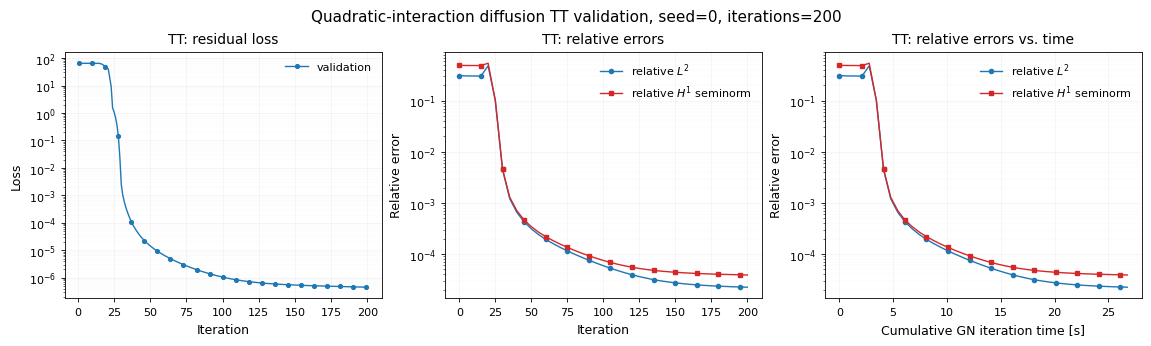

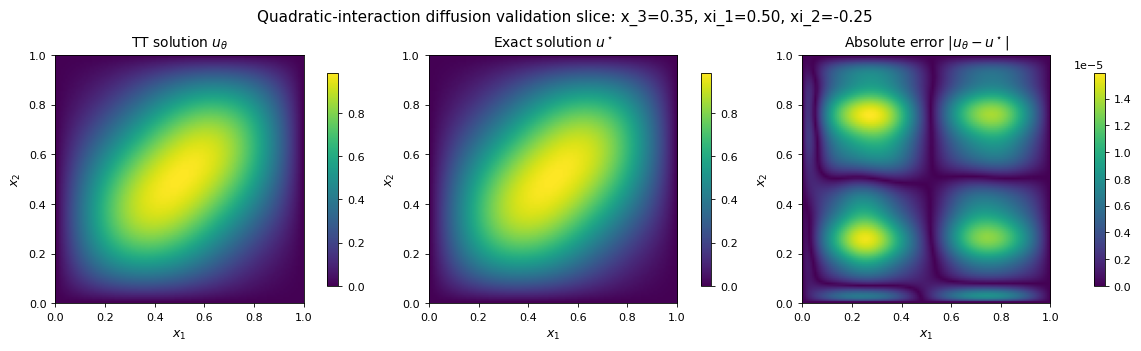

(<Figure size 1140x340 with 6 Axes>,
 array([<Axes: title={'center': 'TT solution $u_\\theta$'}, xlabel='$x_1$', ylabel='$x_2$'>,
        <Axes: title={'center': 'Exact solution $u^\\star$'}, xlabel='$x_1$', ylabel='$x_2$'>,
        <Axes: title={'center': 'Absolute error $|u_\\theta-u^\\star|$'}, xlabel='$x_1$', ylabel='$x_2$'>],
       dtype=object))

In [ ]:
# ------------------------------------------------------------
# Single validation run for the explicitly selected seed.
# The plot has the same three-panel layout as the TT ablation.
# ------------------------------------------------------------
validation_cfg = replace(
    BASE,
    seed=VALIDATION_SEED,
    iterations=VALIDATION_ITERATIONS,
    error_every=VALIDATION_ERROR_EVERY,
)

(
    validation_solver,
    validation_theta,
    validation_scales,
    validation_record,
    validation_history,
) = run(validation_cfg, verbose=True, live_progress=True)

print()
print(f"final relative L2 error:             {validation_record['l2_final']:.4e}")
print(f"best relative L2 error:              {validation_record['l2_best']:.4e}")
print(f"final relative H1 error:             {validation_record['h1_final']:.4e}")
print(f"best relative H1 error:              {validation_record['h1_best']:.4e}")
print(
    "final relative H1-seminorm error: "
    f"{validation_record['h1_seminorm_final']:.4e}"
)
print(f"final accepted residual loss:        {validation_record['loss_final']:.4e}")
print(f"time per GN iteration:               {1e3 * validation_record['t_per_iter']:.1f} ms")
print(f"compiled GN iteration time:          {validation_record['t_run']:.3f} s")
print(f"compilation time:                    {validation_record['t_compile']:.3f} s")
print(
    "linear solver:                       "
    f"{validation_record['solver_used']} / {validation_record['factorization']}"
)

if not validation_cfg.resample_each_iteration:
    accepted_loss = np.asarray(validation_history["loss_after"])
    tolerance = 1e-12 * np.maximum(1.0, np.abs(accepted_loss[:-1]))
    increases = accepted_loss[1:] - accepted_loss[:-1]
    violations = increases > tolerance
    print(f"fixed-grid loss monotonicity violations: {int(np.sum(violations))}")
    if increases.size:
        print(f"largest accepted-loss increase:      {float(np.max(increases)):.3e}")

validation_stem = Path(VALIDATION_RESULT_DIR) / (
    f"quadratic_darcy_tt_sine_exact_hard_constraint_validation_seed_{VALIDATION_SEED}"
)
plot_tt_history(
    validation_history,
    title=(
        rf"Quadratic-interaction diffusion TT validation, seed={VALIDATION_SEED}, "
        rf"iterations={VALIDATION_ITERATIONS}"
    ),
    save_stem=validation_stem,
)

# ------------------------------------------------------------
# 2D physical validation slice at fixed x3,... and fixed xi.
# For D_PHYS=3 this is the x1-x2 plane at x3=0.5 by default.
# ------------------------------------------------------------
validation_slice_stem = Path(VALIDATION_RESULT_DIR) / (
    f"quadratic_darcy_tt_sine_exact_hard_constraint_validation_slice_seed_{VALIDATION_SEED}"
)
plot_validation_solution_slice(
    validation_solver,
    validation_theta,
    validation_scales,
    xi=VALIDATION_SLICE_XI,
    fixed_physical=VALIDATION_SLICE_FIXED_PHYS,
    n=VALIDATION_SLICE_N,
    save_stem=validation_slice_stem,
)


## Consistency checks

Pointwise checks of the exact solution, coefficient and forcing, of the TT contractions against
automatic differentiation, and of the hard boundary constraint. All errors should be at round-off
level.

In [ ]:
# ------------------------------------------------------------
# Analytical and contraction checks.
# These points are diagnostics only; training uses axis-wise factor grids.
# ------------------------------------------------------------
check_key = random.PRNGKey(2026)
unit = random.uniform(check_key, (5, BASE.d))
check_points = unit.at[:, D_PHYS:].set(2.0 * unit[:, D_PHYS:] - 1.0)

exact_value = lambda z: problem.exact(z)[0]
exact_output = vmap(problem.exact)(check_points)
exact_grad_error = float(jnp.max(jnp.abs(
    vmap(jax.grad(exact_value))(check_points)[:, :D_PHYS] - exact_output[1]
)))
exact_lap_error = float(jnp.max(jnp.abs(
    vmap(lambda z: jnp.trace(
        jax.hessian(exact_value)(z)[:D_PHYS, :D_PHYS]
    ))(check_points) - exact_output[2]
)))
kappa_grad_error = float(jnp.max(jnp.abs(
    vmap(jax.grad(lambda z: problem.kappa(z)[0]))(check_points)[:, :D_PHYS]
    - vmap(problem.kappa)(check_points)[1]
)))

# Verify the exact forcing represented by the coefficient-TT residual chain.
forcing_chain_error = float(jnp.max(jnp.abs(
    vmap(validation_solver.exact_forcing_from_chain)(check_points)
    - vmap(problem.forcing)(check_points)
)))


model_operator_chain_error = float(jnp.max(jnp.abs(
    vmap(lambda z: validation_solver.model_operator_from_chain(
        validation_theta, validation_scales, z
    ))(check_points)
    - vmap(lambda z: (
        validation_solver.residual_point(validation_theta, validation_scales, z)
        + problem.forcing(z)
    ))(check_points)
)))

model_value = lambda z: validation_solver.ansatz.evaluate_all(
    validation_theta, validation_scales, z
)[0]
model_output = vmap(lambda z: validation_solver.ansatz.evaluate_all(
    validation_theta, validation_scales, z
))(check_points)
model_grad_error = float(jnp.max(jnp.abs(
    model_output[1]
    - vmap(jax.grad(model_value))(check_points)[:, :D_PHYS]
)))
model_lap_error = float(jnp.max(jnp.abs(
    model_output[2]
    - vmap(lambda z: jnp.trace(
        jax.hessian(model_value)(z)[:D_PHYS, :D_PHYS]
    ))(check_points)
)))

print(f"exact gradient error:          {exact_grad_error:.3e}")
print(f"exact Laplacian error:         {exact_lap_error:.3e}")
print(f"permeability gradient error:   {kappa_grad_error:.3e}")
print(f"coefficient-TT forcing-chain error: {forcing_chain_error:.3e}")
print(f"model coefficient-TT operator error: {model_operator_chain_error:.3e}")
print(f"TT contraction gradient error: {model_grad_error:.3e}")
print(f"TT contraction Laplacian error:{model_lap_error:.3e}")


# The manufactured target uses sine modes, while the neural ansatz uses only
# the generic polynomial cutoff. Both must vanish on the physical boundary.
boundary_points = check_points[:2]
boundary_points = boundary_points.at[0, 0].set(0.0)
boundary_points = boundary_points.at[1, 0].set(1.0)
exact_boundary_error = float(jnp.max(jnp.abs(vmap(exact_value)(boundary_points))))
model_boundary_error = float(jnp.max(jnp.abs(vmap(model_value)(boundary_points))))

print(f"exact sine-target boundary error: {exact_boundary_error:.3e}")
print(f"neural polynomial hard-boundary error: {model_boundary_error:.3e}")

# Coefficient TT (ranks 1, 3, ..., 3, 1) reproduces kappa_quad.
def _coefficient_tt_value(z):
    C = problem.coefficient_cores(z[:, None])[:, 0, 0]
    state = jnp.array([1.0, 0.0, 0.0])
    for m in range(BASE.d):
        state = state @ C[m]
    return state[0]

coefficient_tt_error = float(jnp.max(jnp.abs(
    vmap(_coefficient_tt_value)(check_points) - vmap(problem.kappa)(check_points)[0]
)))
print(f"coefficient TT value error:    {coefficient_tt_error:.3e}")

# Exact TT cores (ranks 1, 2, ..., 2, 1) reproduce u*_quad.
def _exact_tt_value(z):
    U = problem.exact_cores(z[:, None])[:, 0, 0]
    state = jnp.array([1.0, 0.0])
    for m in range(BASE.d):
        state = state @ U[m]
    return state[0]

exact_tt_error = float(jnp.max(jnp.abs(vmap(_exact_tt_value)(check_points) - exact_output[0])))
print(f"exact TT-core value error:     {exact_tt_error:.3e}")
print(
    f"N_eff (solver) = {validation_solver.N_eff}, "
    f"N_eff^ch (proposition) = {darcy_N_eff(D_PHYS, D_PARAM, N_PER_AXIS, TT_RANK)}"
)


exact gradient error:          8.882e-16
exact Laplacian error:         8.882e-15
permeability gradient error:   5.551e-17
coefficient-TT forcing-chain error: 1.066e-14
model coefficient-TT operator error: 2.114e-13
TT contraction gradient error: 6.550e-15
TT contraction Laplacian error:4.263e-14
exact sine-target boundary error: 1.815e-17
neural polynomial hard-boundary error: 0.000e+00
coefficient TT value error:    4.441e-16
exact TT-core value error:     2.776e-16
N_eff (solver) = 8192, N_eff^ch (proposition) = 8192


## Seed ablation

The first cell trains every case in `ABLATION_CASES` for every seed in `ABLATION_SEEDS`. The next
cell plots the results and exports per-seed and summary tables together with the full histories.

In [ ]:
# ------------------------------------------------------------
# Run the TT-only random-seed ablation for all requested cases.
# No plotting is done here.
# ------------------------------------------------------------
if RUN_ABLATION:
    ablation_results = {}
    ablation_template = replace(
        BASE,
        iterations=ABLATION_ITERATIONS,
        error_every=ABLATION_ERROR_EVERY,
    )

    for d_phys, d_param in ABLATION_CASES:
        case_key = case_label(d_phys, d_param)
        case_template = replace(ablation_template, d_phys=int(d_phys), d_param=int(d_param))
        ablation_results[case_key] = {}

        print()
        print("=" * 88)
        print(
            f"Starting TT ablation case {case_key} "
            f"with {len(ABLATION_SEEDS)} seeds, iterations={ABLATION_ITERATIONS}, "
            f"error every {ABLATION_ERROR_EVERY}"
        )
        print("=" * 88)

        for seed in ABLATION_SEEDS:
            seed = int(seed)
            cfg = replace(case_template, seed=seed)
            can_reuse_validation = (
                REUSE_VALIDATION_IN_ABLATION
                and seed == VALIDATION_SEED
                and cfg == validation_cfg
                and "validation_record" in globals()
                and "validation_history" in globals()
            )

            if can_reuse_validation:
                print(
                    f"[TT/{validation_solver.solver_label()}] case={case_key} "
                    f"seed={seed}: reusing validation run"
                )
                record = validation_record
                history = validation_history
            else:
                ab_model, ab_theta, ab_scales, record, history = run(
                    cfg,
                    verbose=True,
                    live_progress=False,
                )
                del ab_model, ab_theta, ab_scales

            ablation_results[case_key][seed] = {"record": record, "history": history}
            gc.collect()
            if CLEAR_JAX_CACHES_BETWEEN_RUNS and not can_reuse_validation:
                jax.clear_caches()

        missing_seeds = [
            int(seed) for seed in ABLATION_SEEDS if int(seed) not in ablation_results[case_key]
        ]
        if missing_seeds:
            raise RuntimeError(
                f"Ablation case {case_key} is incomplete; missing seeds: {missing_seeds}"
            )

    missing_cases = [
        case_label(*case) for case in ABLATION_CASES if case_label(*case) not in ablation_results
    ]
    if missing_cases:
        raise RuntimeError(f"Ablation is incomplete; missing cases: {missing_cases}")

    total_runs = len(ABLATION_CASES) * len(ABLATION_SEEDS)
    print(f"\nTT ablation completed: {total_runs} runs across {len(ABLATION_CASES)} cases.")
    print("Run the next cell to plot, summarize, and export the results.")
else:
    ablation_results = {}
    print("Ablation skipped because RUN_ABLATION=False.")



Starting TT ablation case 3+25 with 10 seeds, iterations=200, error every 10
[TT/compressed] seed=0 d=28=3+25 r=2 P=945772 N_eff=8192 | sampling=fixed_factor_grids | L2=2.240e-05 H1=3.852e-05 grad=3.888e-05 | 133 ms/it
[TT/compressed] seed=10 d=28=3+25 r=2 P=945772 N_eff=8192 | sampling=fixed_factor_grids | L2=3.030e-05 H1=3.205e-05 grad=3.210e-05 | 133 ms/it
[TT/compressed] seed=20 d=28=3+25 r=2 P=945772 N_eff=8192 | sampling=fixed_factor_grids | L2=5.200e-05 H1=1.122e-04 grad=1.135e-04 | 133 ms/it
[TT/compressed] seed=30 d=28=3+25 r=2 P=945772 N_eff=8192 | sampling=fixed_factor_grids | L2=5.724e-05 H1=5.935e-05 grad=5.941e-05 | 133 ms/it
[TT/compressed] seed=40 d=28=3+25 r=2 P=945772 N_eff=8192 | sampling=fixed_factor_grids | L2=6.072e-05 H1=1.114e-04 grad=1.125e-04 | 133 ms/it
[TT/compressed] seed=50 d=28=3+25 r=2 P=945772 N_eff=8192 | sampling=fixed_factor_grids | L2=2.544e-05 H1=3.209e-05 grad=3.226e-05 | 133 ms/it
[TT/compressed] seed=60 d=28=3+25 r=2 P=945772 N_eff=8192 | sampl

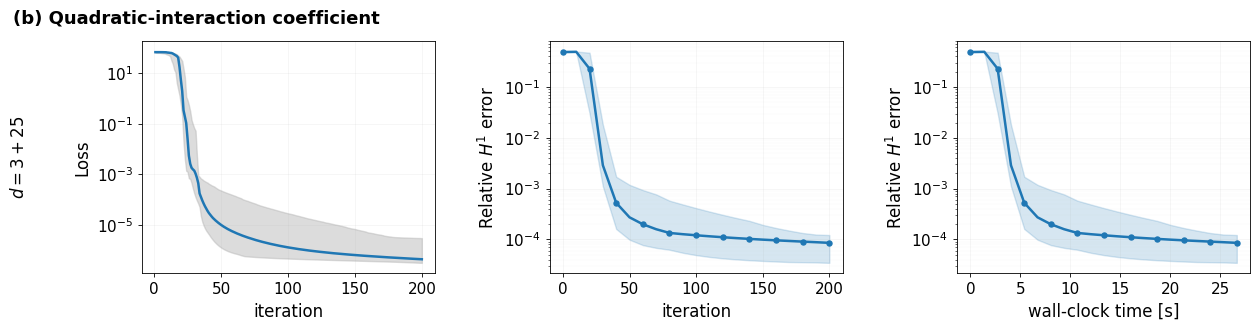

,case,d_phys,d_psi,d_param,total_dimension,seed,relative_L2_final,relative_H1_final,relative_H1_seminorm_final,relative_L2_best,relative_H1_best,loss_final,wall_clock_time_s,ms_per_iteration,solver_requested,solver_used,factorization,parameters,N_eff,coefficient_tt_rank,formal_coefficient_cp_terms,quadratic_parameter_interactions,n_per_axis,sampling_policy
0,3+25,3,25,25,28,0,2.2402e-05,3.8520e-05,3.8885e-05,2.2402e-05,3.8520e-05,4.5237e-07,26.657,133.29,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
1,3+25,3,25,25,28,10,3.0300e-05,3.2047e-05,3.2095e-05,3.0300e-05,3.2047e-05,1.7823e-07,26.670,133.35,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
2,3+25,3,25,25,28,20,5.2001e-05,1.1220e-04,1.1346e-04,5.1105e-05,1.1220e-04,2.4908e-07,26.658,133.29,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
3,3+25,3,25,25,28,30,5.7239e-05,5.9348e-05,5.9407e-05,5.7239e-05,5.9348e-05,4.2636e-07,26.687,133.44,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
4,3+25,3,25,25,28,40,6.0722e-05,1.1141e-04,1.1253e-04,6.0722e-05,1.1141e-04,1.8956e-06,26.653,133.26,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
5,3+25,3,25,25,28,50,2.5437e-05,3.2088e-05,3.2259e-05,2.5437e-05,3.2088e-05,4.1563e-07,26.658,133.29,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
6,3+25,3,25,25,28,60,1.5176e-01,1.6284e-01,1.6315e-01,1.5176e-01,1.6284e-01,4.2100e+00,26.597,132.99,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
7,3+25,3,25,25,28,70,8.0753e-03,8.1451e-03,8.1471e-03,7.9757e-03,8.1194e-03,9.8839e-03,26.679,133.39,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
8,3+25,3,25,25,28,80,8.2733e-05,1.2499e-04,1.2599e-04,8.2733e-05,1.2499e-04,3.3747e-06,26.649,133.24,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
9,3+25,3,25,25,28,90,2.7746e-05,3.3146e-05,3.3288e-05,2.7746e-05,3.3146e-05,2.8338e-07,26.653,133.27,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids


,case,d_phys,d_psi,d_param,total_dimension,avg_relative_L2_final,std_relative_L2_final,avg_relative_H1_seminorm_final,std_relative_H1_seminorm_final,avg_wall_clock_time_s,std_wall_clock_time_s,avg_ms_per_iteration,std_ms_per_iteration
0,3+25,3,25,25,28,1.6019e-02,4.7760e-02,1.7184e-02,5.1348e-02,26.656,0.024,133.28,0.12


saved convergence figure: quadratic_darcy_tt_sine_exact_hard_constraint_multicase_convergence.png and quadratic_darcy_tt_sine_exact_hard_constraint_multicase_convergence.pdf
saved per-seed table:     quadratic_darcy_tt_sine_exact_hard_constraint_seed_ablation.csv
saved summary table:      quadratic_darcy_tt_sine_exact_hard_constraint_seed_ablation_summary.csv
saved complete histories: quadratic_darcy_tt_sine_exact_hard_constraint_histories.json


In [ ]:
# ------------------------------------------------------------
# Plot and export the completed multi-case TT ablation.
# This cell does not train.
# ------------------------------------------------------------


if not RUN_ABLATION:
    raise RuntimeError("Set RUN_ABLATION=True and run the preceding cell first.")

missing_cases = [
    case_label(*case) for case in ABLATION_CASES if case_label(*case) not in ablation_results
]
if missing_cases:
    raise RuntimeError(
        "The ablation is incomplete. Run the training cell first. "
        f"Missing cases: {missing_cases}"
    )

for d_phys, d_param in ABLATION_CASES:
    key = case_label(d_phys, d_param)
    missing_seeds = [
        int(seed) for seed in ABLATION_SEEDS if int(seed) not in ablation_results[key]
    ]
    if missing_seeds:
        raise RuntimeError(
            f"The ablation case {key} is incomplete. Missing seeds: {missing_seeds}"
        )

result_dir = Path(ABLATION_RESULT_DIR)
result_dir.mkdir(parents=True, exist_ok=True)

ablation_stem = result_dir / "quadratic_darcy_tt_sine_exact_hard_constraint_multicase_convergence"
plot_tt_multicase_ablation(
    ablation_results,
    ABLATION_CASES,
    ABLATION_SEEDS,
    title=(
        rf"Quadratic-interaction diffusion TT seed ablation, {len(ABLATION_SEEDS)} seeds per case, "
        rf"iterations={ABLATION_ITERATIONS}"
    ),
    save_stem=ablation_stem,
)

rows = []
summary_rows = []
for d_phys, d_param in ABLATION_CASES:
    key = case_label(d_phys, d_param)
    case_rows = []
    for seed in ABLATION_SEEDS:
        record = ablation_results[key][int(seed)]["record"]
        row = {
            "case": key,
            "d_phys": int(d_phys),
            "d_psi": int(d_param),
            "d_param": int(d_param),
            "total_dimension": int(d_phys + d_param),
            "seed": int(seed),
            "relative_L2_final": record["l2_final"],
            "relative_H1_final": record["h1_final"],
            "relative_H1_seminorm_final": record["h1_seminorm_final"],
            "relative_L2_best": record["l2_best"],
            "relative_H1_best": record["h1_best"],
            "loss_final": record["loss_final"],
            "wall_clock_time_s": record["t_run"],
            "ms_per_iteration": 1e3 * record["t_per_iter"],
            "solver_requested": record["solver_requested"],
            "solver_used": record["solver_used"],
            "factorization": record["factorization"],
            "parameters": record["P"],
            "N_eff": record["N_eff"],
            "coefficient_tt_rank": record["coefficient_tt_rank"],
            "formal_coefficient_cp_terms": record["formal_coefficient_cp_terms"],
            "quadratic_parameter_interactions": record["quadratic_parameter_interactions"],
            "n_per_axis": record["n_per_axis"],
            "sampling_policy": record["sampling_policy"],
        }
        rows.append(row)
        case_rows.append(row)

    case_table = pd.DataFrame(case_rows).sort_values("seed")
    summary_rows.append({
        "case": key,
        "d_phys": int(d_phys),
        "d_psi": int(d_param),
        "d_param": int(d_param),
        "total_dimension": int(d_phys + d_param),
        "avg_relative_L2_final": case_table["relative_L2_final"].mean(),
        "std_relative_L2_final": case_table["relative_L2_final"].std(ddof=1),
        "avg_relative_H1_seminorm_final": case_table["relative_H1_seminorm_final"].mean(),
        "std_relative_H1_seminorm_final": case_table["relative_H1_seminorm_final"].std(ddof=1),
        "avg_wall_clock_time_s": case_table["wall_clock_time_s"].mean(),
        "std_wall_clock_time_s": case_table["wall_clock_time_s"].std(ddof=1),
        "avg_ms_per_iteration": case_table["ms_per_iteration"].mean(),
        "std_ms_per_iteration": case_table["ms_per_iteration"].std(ddof=1),
    })

ablation_table = pd.DataFrame(rows).sort_values(["d_phys", "d_param", "seed"])
summary_table = pd.DataFrame(summary_rows).sort_values(["d_phys", "d_param"])

display(ablation_table.style.format({
    "relative_L2_final": "{:.4e}",
    "relative_H1_final": "{:.4e}",
    "relative_H1_seminorm_final": "{:.4e}",
    "relative_L2_best": "{:.4e}",
    "relative_H1_best": "{:.4e}",
    "loss_final": "{:.4e}",
    "wall_clock_time_s": "{:.3f}",
    "ms_per_iteration": "{:.2f}",
}))

display(summary_table.style.format({
    "avg_relative_L2_final": "{:.4e}",
    "std_relative_L2_final": "{:.4e}",
    "avg_relative_H1_seminorm_final": "{:.4e}",
    "std_relative_H1_seminorm_final": "{:.4e}",
    "avg_wall_clock_time_s": "{:.3f}",
    "std_wall_clock_time_s": "{:.3f}",
    "avg_ms_per_iteration": "{:.2f}",
    "std_ms_per_iteration": "{:.2f}",
}))

csv_path = result_dir / "quadratic_darcy_tt_sine_exact_hard_constraint_seed_ablation.csv"
summary_csv_path = result_dir / "quadratic_darcy_tt_sine_exact_hard_constraint_seed_ablation_summary.csv"
json_path = result_dir / "quadratic_darcy_tt_sine_exact_hard_constraint_histories.json"

ablation_table.to_csv(csv_path, index=False)
summary_table.to_csv(summary_csv_path, index=False)

payload = {
    "settings": {
        "validation_base": asdict(BASE),
        "cases": [
            {"d_phys": int(d_phys), "d_psi": int(d_param), "d_param": int(d_param), "label": case_label(d_phys, d_param)}
            for d_phys, d_param in ABLATION_CASES
        ],
        "seeds": [int(seed) for seed in ABLATION_SEEDS],
        "iterations": int(ABLATION_ITERATIONS),
        "error_every": int(ABLATION_ERROR_EVERY),
        "method": "TT + auto-selected dense-Cholesky/compressed-LU Gauss--Newton",
        "tt_ranks": "(1, r, ..., r, 1)",
        "solver_request": SOLVER,
        "coefficient": "kappa=(1+alpha*psi(x)*sum_j w_j xi_j)^2 retained as rank-three TT",
        "manufactured_solution": "two sine-based spatial modes; maximal TT rank two",
        "hard_boundary_factor": "sqrt(30)*x*(1-x); no sine factor embedded in neural cores",
        "collocation": "axis-wise factor grids; implied tensor grid never formed",
    },
    "runs": {
        case_label(d_phys, d_param): {
            str(seed): {
                "record": ablation_results[case_label(d_phys, d_param)][int(seed)]["record"],
                "history": json_history(ablation_results[case_label(d_phys, d_param)][int(seed)]["history"]),
            }
            for seed in ABLATION_SEEDS
        }
        for d_phys, d_param in ABLATION_CASES
    },
}
with open(json_path, "w") as file:
    json.dump(payload, file, indent=2)

print(f"saved convergence figure: {ablation_stem}.png and {ablation_stem}.pdf")
print(f"saved per-seed table:     {csv_path}")
print(f"saved summary table:      {summary_csv_path}")
print(f"saved complete histories: {json_path}")


The last cell re-plots and exports only the cases listed in `PLOT_CASES` (here $3+25$), without
retraining.

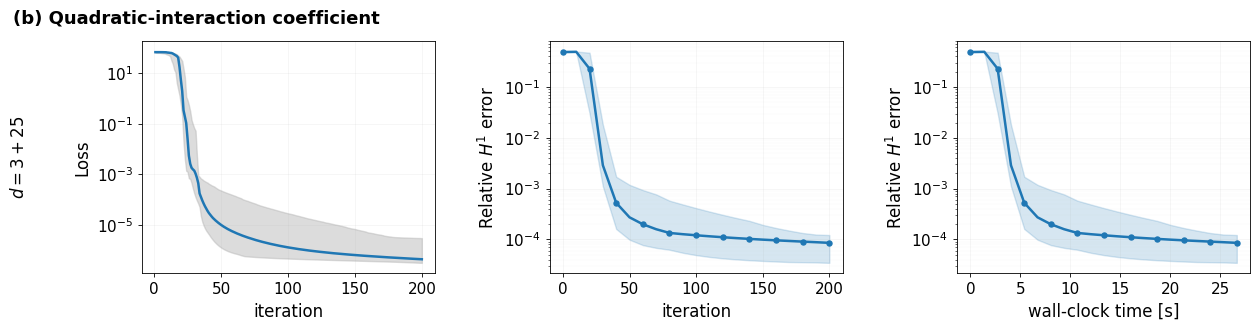

,case,d_phys,d_psi,d_param,total_dimension,seed,relative_L2_final,relative_H1_final,relative_H1_seminorm_final,relative_L2_best,relative_H1_best,loss_final,wall_clock_time_s,ms_per_iteration,solver_requested,solver_used,factorization,parameters,N_eff,coefficient_tt_rank,formal_coefficient_cp_terms,quadratic_parameter_interactions,n_per_axis,sampling_policy
0,3+25,3,25,25,28,0,2.2402e-05,3.8520e-05,3.8885e-05,2.2402e-05,3.8520e-05,4.5237e-07,26.657,133.29,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
1,3+25,3,25,25,28,10,3.0300e-05,3.2047e-05,3.2095e-05,3.0300e-05,3.2047e-05,1.7823e-07,26.670,133.35,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
2,3+25,3,25,25,28,20,5.2001e-05,1.1220e-04,1.1346e-04,5.1105e-05,1.1220e-04,2.4908e-07,26.658,133.29,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
3,3+25,3,25,25,28,30,5.7239e-05,5.9348e-05,5.9407e-05,5.7239e-05,5.9348e-05,4.2636e-07,26.687,133.44,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
4,3+25,3,25,25,28,40,6.0722e-05,1.1141e-04,1.1253e-04,6.0722e-05,1.1141e-04,1.8956e-06,26.653,133.26,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
5,3+25,3,25,25,28,50,2.5437e-05,3.2088e-05,3.2259e-05,2.5437e-05,3.2088e-05,4.1563e-07,26.658,133.29,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
6,3+25,3,25,25,28,60,1.5176e-01,1.6284e-01,1.6315e-01,1.5176e-01,1.6284e-01,4.2100e+00,26.597,132.99,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
7,3+25,3,25,25,28,70,8.0753e-03,8.1451e-03,8.1471e-03,7.9757e-03,8.1194e-03,9.8839e-03,26.679,133.39,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
8,3+25,3,25,25,28,80,8.2733e-05,1.2499e-04,1.2599e-04,8.2733e-05,1.2499e-04,3.3747e-06,26.649,133.24,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids
9,3+25,3,25,25,28,90,2.7746e-05,3.3146e-05,3.3288e-05,2.7746e-05,3.3146e-05,2.8338e-07,26.653,133.27,auto,compressed,pivoted_lu,945772,8192,3,351,300,64,fixed_factor_grids


,case,d_phys,d_psi,d_param,total_dimension,avg_relative_L2_final,std_relative_L2_final,avg_relative_H1_seminorm_final,std_relative_H1_seminorm_final,avg_wall_clock_time_s,std_wall_clock_time_s,avg_ms_per_iteration,std_ms_per_iteration
0,3+25,3,25,25,28,1.6019e-02,4.7760e-02,1.7184e-02,5.1348e-02,26.656,0.024,133.28,0.12



Exported cases:
  3+25

saved convergence figure: quadratic_darcy_tt_sine_exact_hard_constraint_3p25_convergence.png and quadratic_darcy_tt_sine_exact_hard_constraint_3p25_convergence.pdf
saved per-seed table:     quadratic_darcy_tt_sine_exact_hard_constraint_3p25_seed_ablation.csv
saved summary table:      quadratic_darcy_tt_sine_exact_hard_constraint_3p25_seed_ablation_summary.csv
saved complete histories: quadratic_darcy_tt_sine_exact_hard_constraint_3p25_histories.json


In [ ]:
# ------------------------------------------------------------
# Plot and export selected completed TT ablation cases.
# This cell does not train.
# Currently exports only the 3+25 case.
# ------------------------------------------------------------
if not RUN_ABLATION:
    raise RuntimeError(
        "Set RUN_ABLATION=True and run the preceding training cell first."
    )

# ------------------------------------------------------------
# Select only the cases that should be plotted/exported.
# This does NOT modify ABLATION_CASES or retrain anything.
# ------------------------------------------------------------
PLOT_CASES = [(3, 25)]

# ------------------------------------------------------------
# Check that the selected cases exist.
# ------------------------------------------------------------
missing_cases = [
    case_label(*case)
    for case in PLOT_CASES
    if case_label(*case) not in ablation_results
]

if missing_cases:
    raise RuntimeError(
        "The selected ablation cases have not been trained. "
        f"Missing cases: {missing_cases}"
    )

# ------------------------------------------------------------
# Check that all requested seeds are available for each
# selected case.
# ------------------------------------------------------------
for d_phys, d_param in PLOT_CASES:
    key = case_label(d_phys, d_param)

    missing_seeds = [
        int(seed)
        for seed in ABLATION_SEEDS
        if int(seed) not in ablation_results[key]
    ]

    if missing_seeds:
        raise RuntimeError(
            f"The selected ablation case {key} is incomplete. "
            f"Missing seeds: {missing_seeds}"
        )

# ------------------------------------------------------------
# Output directory.
# ------------------------------------------------------------
result_dir = Path(ABLATION_RESULT_DIR)
result_dir.mkdir(parents=True, exist_ok=True)

# Use a separate filename so we do not overwrite a future
# complete multi-case ablation.
case_tag = "_".join(
    case_label(d_phys, d_param).replace("+", "p")
    for d_phys, d_param in PLOT_CASES
)

ablation_stem = (
    result_dir
    / f"quadratic_darcy_tt_sine_exact_hard_constraint_{case_tag}_convergence"
)

# ------------------------------------------------------------
# Plot convergence histories.
# ------------------------------------------------------------
plot_tt_multicase_ablation(
    ablation_results,
    PLOT_CASES,
    ABLATION_SEEDS,
    title=(
        rf"Quadratic-interaction diffusion TT seed ablation, "
        rf"case {case_label(*PLOT_CASES[0])}, "
        rf"{len(ABLATION_SEEDS)} seeds, "
        rf"iterations={ABLATION_ITERATIONS}"
    ),
    save_stem=ablation_stem,
)

# ------------------------------------------------------------
# Construct per-seed and summary tables.
# ------------------------------------------------------------
rows = []
summary_rows = []

for d_phys, d_param in PLOT_CASES:
    key = case_label(d_phys, d_param)
    case_rows = []

    for seed in ABLATION_SEEDS:
        record = ablation_results[key][int(seed)]["record"]

        row = {
            "case": key,
            "d_phys": int(d_phys),
            "d_psi": int(d_param),
            "d_param": int(d_param),
            "total_dimension": int(d_phys + d_param),
            "seed": int(seed),

            "relative_L2_final": record["l2_final"],
            "relative_H1_final": record["h1_final"],
            "relative_H1_seminorm_final": record["h1_seminorm_final"],

            "relative_L2_best": record["l2_best"],
            "relative_H1_best": record["h1_best"],

            "loss_final": record["loss_final"],

            "wall_clock_time_s": record["t_run"],
            "ms_per_iteration": 1e3 * record["t_per_iter"],

            "solver_requested": record["solver_requested"],
            "solver_used": record["solver_used"],
            "factorization": record["factorization"],

            "parameters": record["P"],
            "N_eff": record["N_eff"],

            "coefficient_tt_rank": record["coefficient_tt_rank"],
            "formal_coefficient_cp_terms": record["formal_coefficient_cp_terms"],
            "quadratic_parameter_interactions": record[
                "quadratic_parameter_interactions"
            ],

            "n_per_axis": record["n_per_axis"],
            "sampling_policy": record["sampling_policy"],
        }

        rows.append(row)
        case_rows.append(row)

    case_table = pd.DataFrame(case_rows).sort_values("seed")

    summary_rows.append({
        "case": key,
        "d_phys": int(d_phys),
        "d_psi": int(d_param),
        "d_param": int(d_param),
        "total_dimension": int(d_phys + d_param),

        "avg_relative_L2_final":
            case_table["relative_L2_final"].mean(),
        "std_relative_L2_final":
            case_table["relative_L2_final"].std(ddof=1),

        "avg_relative_H1_seminorm_final":
            case_table["relative_H1_seminorm_final"].mean(),
        "std_relative_H1_seminorm_final":
            case_table["relative_H1_seminorm_final"].std(ddof=1),

        "avg_wall_clock_time_s":
            case_table["wall_clock_time_s"].mean(),
        "std_wall_clock_time_s":
            case_table["wall_clock_time_s"].std(ddof=1),

        "avg_ms_per_iteration":
            case_table["ms_per_iteration"].mean(),
        "std_ms_per_iteration":
            case_table["ms_per_iteration"].std(ddof=1),
    })

# ------------------------------------------------------------
# Convert to DataFrames.
# ------------------------------------------------------------
ablation_table = (
    pd.DataFrame(rows)
    .sort_values(["d_phys", "d_param", "seed"])
)

summary_table = (
    pd.DataFrame(summary_rows)
    .sort_values(["d_phys", "d_param"])
)

# ------------------------------------------------------------
# Display per-seed results.
# ------------------------------------------------------------
display(
    ablation_table.style.format({
        "relative_L2_final": "{:.4e}",
        "relative_H1_final": "{:.4e}",
        "relative_H1_seminorm_final": "{:.4e}",
        "relative_L2_best": "{:.4e}",
        "relative_H1_best": "{:.4e}",
        "loss_final": "{:.4e}",
        "wall_clock_time_s": "{:.3f}",
        "ms_per_iteration": "{:.2f}",
    })
)

# ------------------------------------------------------------
# Display summary statistics.
# ------------------------------------------------------------
display(
    summary_table.style.format({
        "avg_relative_L2_final": "{:.4e}",
        "std_relative_L2_final": "{:.4e}",
        "avg_relative_H1_seminorm_final": "{:.4e}",
        "std_relative_H1_seminorm_final": "{:.4e}",
        "avg_wall_clock_time_s": "{:.3f}",
        "std_wall_clock_time_s": "{:.3f}",
        "avg_ms_per_iteration": "{:.2f}",
        "std_ms_per_iteration": "{:.2f}",
    })
)

# ------------------------------------------------------------
# Export tables and complete histories.
# ------------------------------------------------------------
csv_path = (
    result_dir
    / f"quadratic_darcy_tt_sine_exact_hard_constraint_{case_tag}_seed_ablation.csv"
)

summary_csv_path = (
    result_dir
    / f"quadratic_darcy_tt_sine_exact_hard_constraint_{case_tag}_seed_ablation_summary.csv"
)

json_path = (
    result_dir
    / f"quadratic_darcy_tt_sine_exact_hard_constraint_{case_tag}_histories.json"
)

ablation_table.to_csv(csv_path, index=False)
summary_table.to_csv(summary_csv_path, index=False)

# ------------------------------------------------------------
# JSON payload: export ONLY PLOT_CASES.
# ------------------------------------------------------------
payload = {
    "settings": {
        "validation_base": asdict(BASE),

        "cases": [
            {
                "d_phys": int(d_phys),
                "d_psi": int(d_param),
                "d_param": int(d_param),
                "label": case_label(d_phys, d_param),
            }
            for d_phys, d_param in PLOT_CASES
        ],

        "seeds": [
            int(seed)
            for seed in ABLATION_SEEDS
        ],

        "iterations": int(ABLATION_ITERATIONS),
        "error_every": int(ABLATION_ERROR_EVERY),

        "method": (
            "TT + auto-selected dense-Cholesky/"
            "compressed-LU Gauss--Newton"
        ),

        "solver_request": SOLVER,

        "coefficient": (
            "kappa=(1+alpha*psi(x)*sum_j w_j xi_j)^2 "
            "retained as rank-three TT"
        ),

        "manufactured_solution": (
            "two sine-based spatial modes; maximal TT rank two"
        ),

        "hard_boundary_factor": (
            "sqrt(30)*x*(1-x); "
            "no sine factor embedded in neural cores"
        ),

        "collocation": (
            "axis-wise factor grids; "
            "implied tensor grid never formed"
        ),
    },

    "runs": {
        case_label(d_phys, d_param): {
            str(seed): {
                "record": (
                    ablation_results[
                        case_label(d_phys, d_param)
                    ][int(seed)]["record"]
                ),

                "history": json_history(
                    ablation_results[
                        case_label(d_phys, d_param)
                    ][int(seed)]["history"]
                ),
            }
            for seed in ABLATION_SEEDS
        }
        for d_phys, d_param in PLOT_CASES
    },
}

with open(json_path, "w") as file:
    json.dump(payload, file, indent=2)

# ------------------------------------------------------------
# Report saved files.
# ------------------------------------------------------------
print()
print("Exported cases:")
for d_phys, d_param in PLOT_CASES:
    print(f"  {case_label(d_phys, d_param)}")

print()
print(
    f"saved convergence figure: "
    f"{ablation_stem}.png and {ablation_stem}.pdf"
)
print(f"saved per-seed table:     {csv_path}")
print(f"saved summary table:      {summary_csv_path}")
print(f"saved complete histories: {json_path}")